(sargent_surico)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 货币数量论的两个例证

```{index} single: Quantity Theory of Money
```

```{contents} Contents
:depth: 2
```

除了 Anaconda 中已有的内容之外，本讲座使用 `pandas_datareader` 下载宏观经济数据，并使用 `jax`、`numpyro` 和 `arviz` 来完成末尾的哈密顿蒙特卡洛部分：

In [1]:
!pip install pandas_datareader numpyro jax arviz

## 概览

{cite:t}`Lucas1980` 绘制了美国通货膨胀的长期移动平均值与美国货币增长的长期移动平均值之间的散点图，随后又绘制了名义利率的长期移动平均值与相同的货币增长移动平均值之间的散点图。

两幅散点图都紧贴着 45 度线。

卢卡斯将这两个单位斜率解读为体现了"货币数量论的两个核心含义：货币量变化率的给定变化会引起（一）价格通胀率的等量变化；以及（二）名义利率的等量变化"。

他也警告说，一种理论会告诉我们"在什么条件下人们可以预期这些结论会失效"。

本讲座研究 {cite:t}`SargentSurico2011`，该文认真对待了这一警告。

该论文做了三件事。

第一，它扩展了卢卡斯的样本，表明他的两个斜率在不同的子时期中并*不*稳定。

第二，遵循 {cite:t}`Whiteman1984` 的思路，将卢卡斯的斜率解释为双边分布滞后回归中系数之和，这一对象由时间序列模型给出，是在零频率处的谱密度之比。

第三，它在 1984 年之前的样本上估计了一个小型新凯恩斯模型，然后*仅*扰动货币政策规则，表明单凭政策就能使这两个斜率在数据所显示的范围内移动。

我们将在 Python 中从零开始完成所有这些工作。

我们编写了自己的线性理性预期模型求解器、自己的卡尔曼滤波器，以及自己的 Metropolis-Hastings 采样器，以便让每一步都清晰可见。

最后一节则将估计出的模型用作哈密顿蒙特卡洛的测试平台，结果发现这需要将模型求解器替换为一个可微的求解器。

在此过程中，我们标出了几处已发表论文对其模型的陈述或实现需要谨慎对待的地方，并对每一处都进行了数值检验。

大多数是修正，其中有一处结果反而使论文的结论更加鲜明，而非削弱了它。

让我们从导入模块开始。

In [2]:
import datetime
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from scipy import optimize, stats
from scipy.linalg import ordqz, solve_discrete_lyapunov, svd
from scipy.stats import invwishart

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 卢卡斯的移动平均

对于一个标量序列 $x_t$ 及 $\beta \in [0, 1)$，{cite:t}`Lucas1980` 构造了如下的双边移动平均

$$
\bar x_t(\beta) = a \sum_{k=-n}^{n} \beta^{|k|} x_{t+k},
\qquad
a = \frac{(1-\beta)^2}{1 - \beta^2 - 2\beta^{n+1}(1-\beta)} ,
$$ (eq:ss_filter)

其中 $a$ 使得权重之和为一。

$\beta$ 越大意味着序列越平滑、窗口越长。

设定 $\beta = 0$ 则还原为原始数据。

我们将权重应用于所有可用的观测值，并重新归一化使其始终求和为一。

In [3]:
def lucas_filter(x, beta=0.95):
    """Two-sided exponentially weighted moving average of Lucas (1980)."""
    x = np.asarray(x, dtype=float)
    T = len(x)
    out = np.empty(T)
    for t in range(T):
        w = beta ** np.abs(np.arange(T) - t)
        out[t] = w @ x / w.sum()
    return out

## 怀特曼的重新解释

{cite:t}`Whiteman1984` 观察到，用一条直线拟合移动平均的散点图，是一种非正式的方法，用来计算长双边分布滞后回归中系数的*总和*。

设 $\{y_t, z_t\}$ 联合协方差平稳且均值为零，将 $y_t$ 投影到 $z$ 的全部历史与未来上，

$$
y_t = \sum_{j=-\infty}^{\infty} h_j z_{t-j} + \epsilon_t ,
\qquad \mathbb{E}\, \epsilon_t z_{t-j} = 0 \ \ \forall j .
$$ (eq:ss_twosided)

记 $S_y(\omega)$、$S_z(\omega)$ 与 $S_{yz}(\omega)$ 分别为谱密度和交叉谱密度，$h(\omega) = \sum_j h_j e^{-i\omega j}$ 为传递函数。

那么

$$
h(\omega) = \frac{S_{yz}(\omega)}{S_z(\omega)}
\qquad \text{so} \qquad
\sum_{j=-\infty}^{\infty} h_j = h(0) = \frac{S_{yz}(0)}{S_z(0)} .
$$ (eq:ss_h0)

怀特曼证明了当 $\beta \to 1$ 时，$\bar y_t(\beta)$ 对 $\bar z_t(\beta)$ 的回归系数收敛于 $h(0)$。

因此卢卡斯的两个例证实际上是主张

$$
h_{\pi, \Delta m}(0) = 1
\qquad \text{and} \qquad
h_{R, \Delta m}(0) = 1 ,
$$

其中 $\pi$ 是通货膨胀，$\Delta m$ 是货币增长，$R$ 是名义利率。

这是一个有用的重新表述，因为 $h(0)$ 是一个*总体*对象，任何时间序列模型都能给出这一数值。

### 从状态空间模型到 $h(0)$

假设某个模型蕴含

$$
X_{t+1} = A X_t + B W_{t+1},
\qquad
Y_{t+1} = C X_t + D W_{t+1},
$$ (eq:ss_statespace)

其中 $W_{t+1}$ 是一个标准正态向量，随时间独立同分布，且 $A$ 是稳定的。

迭代给出 $X_t = \sum_{j \ge 0} A^j B W_{t-j}$，因此从 $W$ 到 $Y$ 的传递函数为

$$
H(\zeta) = D + \zeta \, C (I - A\zeta)^{-1} B ,
\qquad \zeta = e^{-i\omega},
$$

而 $Y$ 的谱密度矩阵为 $S_Y(\omega) = H(\zeta) H(\zeta)^{*} / (2\pi)$，即

$$
2\pi S_Y(\omega) =
C (I - A e^{-i\omega})^{-1} B B' (I - A' e^{i\omega})^{-1} C'
+ D D'
+ e^{-i\omega} C (I - A e^{-i\omega})^{-1} B D'
+ e^{i\omega} D B' (I - A' e^{i\omega})^{-1} C' .
$$ (eq:ss_spectrum)

```{note}
{cite:t}`SargentSurico2011` 的方程 (7) 只报告了 {eq}`eq:ss_spectrum` 的前两项。

当 $B D' = 0$ 时，即推动状态变化的冲击与作用于观测方程的冲击相互正交时，这两个交叉项才会恰好消失。

一个一行的例子说明它们在其他情况下是重要的：取标量 $A = 1/2$、$B = C = D = 1$，正确的 $2\pi S_Y(0)$ 为 $(1 + 1/(1-1/2))^2 = 9$，而截断公式给出的却是 $1/(1-1/2)^2 + 1 = 5$。

不过后文的内容不受此影响，因为我们把 VAR 和求解得到的模型都写成 $D = 0$ 的形式，这也是书写各自模型的自然方式。
```

在 $\omega = 0$ 且 $D = 0$ 时，一切都化简为一个长期乘数。

记 $G = C(I - A)^{-1}B$，

$$
2\pi S_Y(0) = G G' ,
\qquad
h_{y,z}(0) = \frac{[G G']_{yz}}{[G G']_{zz}} .
$$ (eq:ss_h0state)

In [4]:
def h_zero_from_state_space(A, B, C, iy, iz):
    """h(0) for observable iy regressed on observable iz."""
    G = np.linalg.solve(np.eye(A.shape[0]) - A, B)
    S0 = C @ G @ G.T @ C.T
    return S0[iy, iz] / S0[iz, iz]

## 数据

{cite:t}`SargentSurico2011` 将 FRED 数据与 {cite:t}`BalkeGordon1986` 的历史序列拼接，以追溯到 1900 年。

那些历史序列在 FRED 上并不存在，因此我们使用 FRED 确实提供的 1959 年之后的季度数据，并将样本延伸到论文 2005 年终点之后的二十年。

这一延伸正是有趣之处：它涵盖了 2008 年后和 2020 年后的资产负债表扩张，以及 2021-2023 年的通货膨胀。

我们用 M2 代表货币，GDP 平减指数代表价格，实际 GDP 代表产出，三个月期国库券利率代表名义利率。

论文的基准是六个月期商业票据利率，FRED 已不再提供该数据；其附录表 A 显示三个月期国库券给出了相似的结果。

货币增长、通货膨胀和产出增长为季度对数差分乘以 100，利率除以四，使其也成为以百分比表示的季度利率。

In [5]:
start, end = datetime.datetime(1959, 1, 1), datetime.datetime(2030, 1, 1)
raw = web.DataReader(['M2SL', 'GDPDEF', 'GDPC1', 'TB3MS'], 'fred', start, end)

q = pd.DataFrame({'M2': raw['M2SL'].resample('QS').mean(),
                  'P': raw['GDPDEF'].resample('QS').mean(),
                  'Y': raw['GDPC1'].resample('QS').mean(),
                  'R': raw['TB3MS'].resample('QS').mean() / 4}).dropna()

data = pd.DataFrame({'dm': 100 * np.log(q['M2']).diff(),
                     'pi': 100 * np.log(q['P']).diff(),
                     'dy': 100 * np.log(q['Y']).diff(),
                     'R': q['R']}).dropna()

VARS = ['dm', 'pi', 'R', 'dy']
LABELS = {'dm': 'M2 growth', 'pi': 'inflation',
          'R': 'T-bill rate', 'dy': 'real GDP growth'}
print(f"sample: {data.index[0].date()} to {data.index[-1].date()},  T = {len(data)}")
data.describe().round(3)

sample: 1959-04-01 to 2026-04-01,  T = 269


,dm,pi,dy,R
count,269.000,269.000,269.000,269.000
mean,1.629,0.808,0.736,1.090
std,1.116,0.576,1.051,0.771
min,-1.700,-0.399,-8.204,0.003
25%,1.098,0.422,0.341,0.511
50%,1.606,0.632,0.751,1.100
75%,2.093,1.027,1.127,1.434
max,12.448,2.899,7.476,3.763


以下是原始序列及其 $\beta = 0.95$ 移动平均。

阴影区域标出了 1959-1975 年，这是我们能够最接近卢卡斯所用窗口的时段。

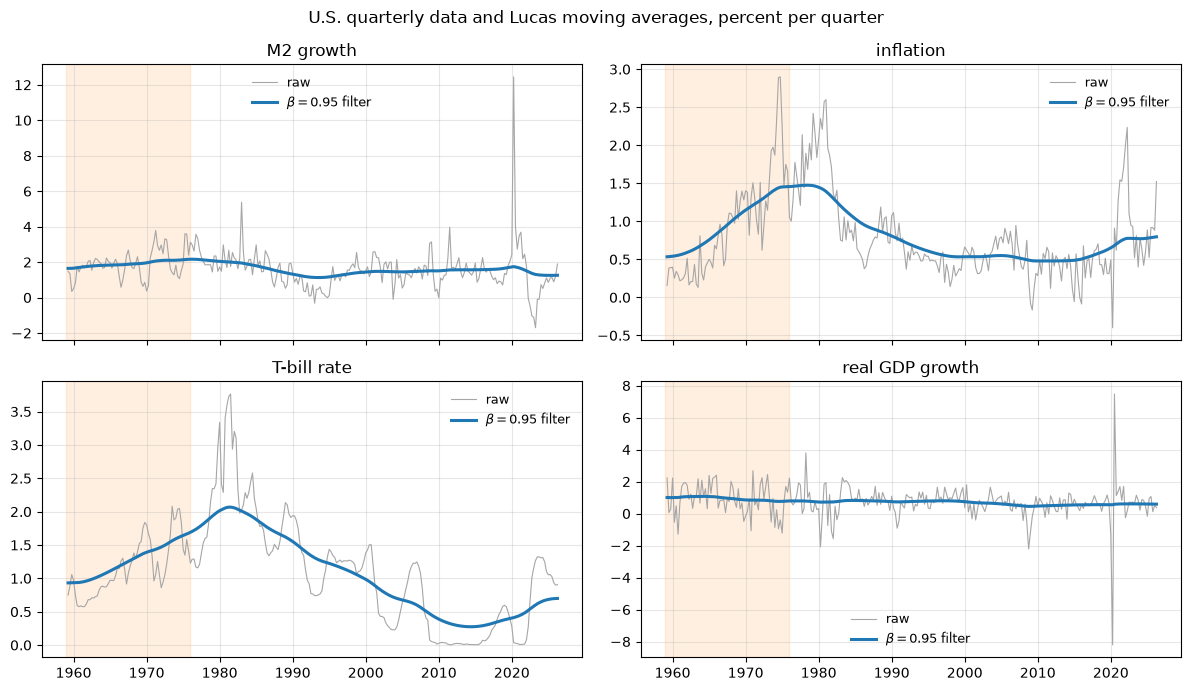

In [6]:
filtered = pd.DataFrame({c: lucas_filter(data[c].values, 0.95) for c in VARS},
                        index=data.index)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, c in zip(axes.flat, VARS):
    ax.plot(data.index, data[c], lw=0.8, color='0.65', label='raw')
    ax.plot(filtered.index, filtered[c], lw=2.2, color='C0',
            label=r'$\beta = 0.95$ filter')
    ax.axvspan(pd.Timestamp('1959-01-01'), pd.Timestamp('1975-12-31'),
               color='C1', alpha=0.12)
    ax.set_title(LABELS[c])
    ax.legend(frameon=False, fontsize=9)
fig.suptitle('U.S. quarterly data and Lucas moving averages, percent per quarter')
plt.tight_layout()
plt.show()

货币增长、通货膨胀和利率在 20 世纪 80 年代初之前一同上升，随后又一同下降。

1984 年以后，这种共同变动就很难看到了，而疫情期间 M2 增长的激增则完全独立于其他一切。

## 散点图

按照论文的做法，我们绘制每年第二季度的观测值，这样可以减少相邻滤波值之间的重叠。

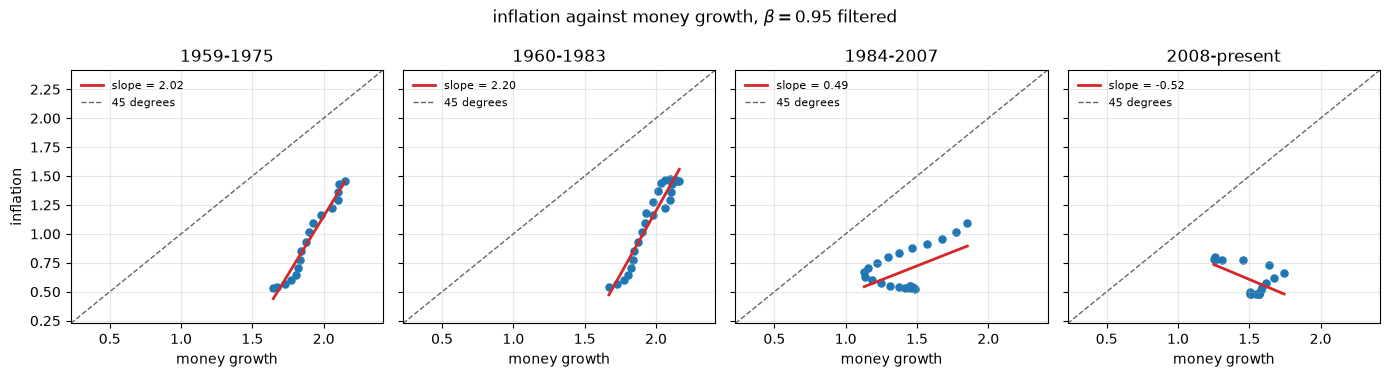

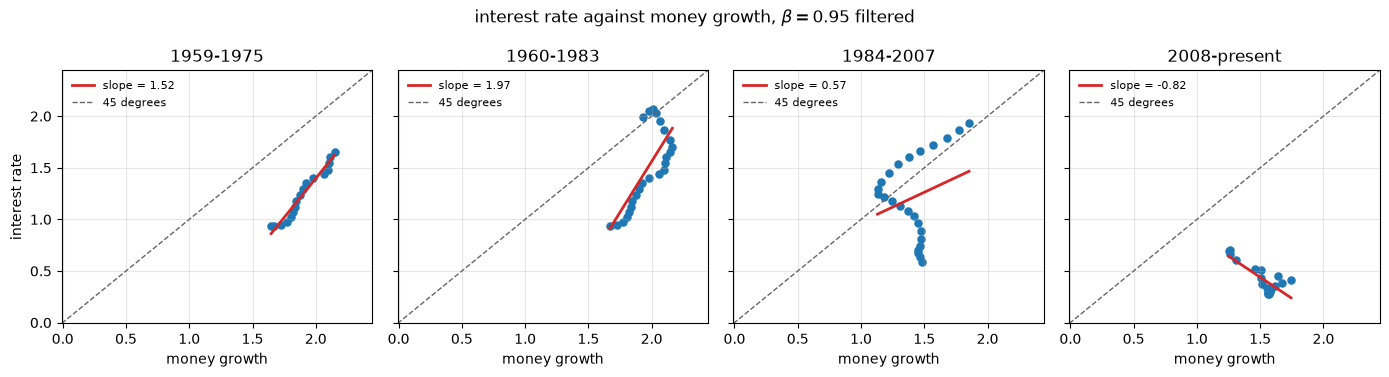

In [7]:
PERIODS = [('1959-1975', 1959, 1975), ('1960-1983', 1960, 1983),
           ('1984-2007', 1984, 2007), ('2008-present', 2008, 2100)]


def scatter_panel(yvar, title):
    q2 = filtered[filtered.index.quarter == 2]
    pad = 0.15 * (q2[['dm', yvar]].values.max() - q2[['dm', yvar]].values.min())
    lim = np.array([q2[['dm', yvar]].values.min() - pad,
                    q2[['dm', yvar]].values.max() + pad])
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), sharex=True, sharey=True)
    for ax, (name, lo, hi) in zip(axes, PERIODS):
        sub = q2[(q2.index.year >= lo) & (q2.index.year <= hi)]
        x, y = sub['dm'].values, sub[yvar].values
        ax.scatter(x, y, s=26, color='C0')
        b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 2)
        ax.plot(xx, np.polyval(b, xx), color='C3', lw=2,
                label=f'slope = {b[0]:.2f}')
        ax.plot(lim, lim, color='0.4', ls='--', lw=1, label='45 degrees')
        ax.set(xlim=lim, ylim=lim, title=name, xlabel='money growth')
        ax.legend(frameon=False, fontsize=8, loc='upper left')
    axes[0].set_ylabel(title)
    fig.suptitle(f'{title} against money growth, $\\beta = 0.95$ filtered')
    plt.tight_layout()
    plt.show()


scatter_panel('pi', 'inflation')
scatter_panel('R', 'interest rate')

卢卡斯所用窗口以及沃尔克之前的样本都紧贴 45 度线。

而大缓和时期以及 2008 年以来的时期则并非如此。

## 对滤波数据的回归

论文的表 1 报告了这些斜率在一系列 $\beta$ 值下的结果。

In [8]:
def filtered_slopes(betas=(0.95, 0.8, 0.5, 0.0)):
    rows = {}
    for beta in betas:
        f = pd.DataFrame({c: lucas_filter(data[c].values, beta) for c in VARS},
                         index=data.index)
        for name, lo, hi in PERIODS + [('full sample', 1900, 2100)]:
            m = ((f.index.year >= lo) & (f.index.year <= hi)
                 & (f.index.quarter == 2))
            x = f.loc[m, 'dm'].values
            rows.setdefault(name, {})[('pi on dm', beta)] = np.polyfit(x, f.loc[m, 'pi'], 1)[0]
            rows[name][('R on dm', beta)] = np.polyfit(x, f.loc[m, 'R'], 1)[0]
    tab = pd.DataFrame(rows).T
    order = [(v, b) for v in ['pi on dm', 'R on dm'] for b in betas]
    return tab.reindex(columns=order)


filtered_slopes().round(2)

pi on dm                   R on dm                  
                 0.95  0.80  0.50  0.00    0.95  0.80  0.50  0.00
1959-1975        2.02  1.06  0.24  0.01    1.52  0.54 -0.02 -0.12
1960-1983        2.20  1.14  0.23  0.04    1.97  0.94  0.15  0.05
1984-2007        0.49  0.02 -0.04 -0.03    0.57  0.23  0.21  0.08
2008-present    -0.52 -0.08 -0.05 -0.08   -0.82 -0.33 -0.15 -0.06
full sample      0.85  0.39  0.10 -0.04    0.90  0.30  0.04 -0.03

有两个模式很突出。

$\beta$ 越接近一，斜率就越大，这与卢卡斯的图形以及论文表 1 中的结果完全一致。

并且随着样本的推进，斜率稳步下降，从卢卡斯所用窗口中的大于一，到 2008 年之后变为负值。

## 从 VAR 估计 $h(0)$

对滤波数据的回归是非正式的。

方程 {eq}`eq:ss_h0state` 让我们可以从拟合的 VAR 中正确地计算出 $h(0)$。

我们对货币增长、通货膨胀、利率和产出增长拟合一个 VAR(2)模型，将其化为伴随形式，并从长期乘数矩阵中读出 $h(0)$。

我们使用弥散先验，以便能够报告后验带，这与论文图 5 的做法一致。

如果某次抽取的伴随矩阵是爆炸性的，则将其舍弃，因为 $h(0)$ 对这些情形没有定义。

In [9]:
def bvar_h0(Y, p=2, n_draws=500, seed=0):
    """Posterior draws of h(0) from a VAR(p) under a diffuse prior."""
    rng = np.random.default_rng(seed)
    T, n = Y.shape
    X = np.column_stack([np.ones(T - p)] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    Z, k = Y[p:], 1 + n * p
    XXi = np.linalg.inv(X.T @ X)
    B_hat = XXi @ X.T @ Z
    E = Z - X @ B_hat
    S, nu = E.T @ E, T - p - k
    L_x = np.linalg.cholesky(XXi)
    J = np.vstack([np.eye(n), np.zeros((n * (p - 1), n))])

    out = np.full((n_draws, 2), np.nan)
    for d in range(n_draws):
        Sigma = invwishart.rvs(df=nu, scale=S, random_state=rng)
        B = B_hat + L_x @ rng.standard_normal((k, n)) @ np.linalg.cholesky(Sigma).T
        A = np.zeros((n * p, n * p))
        A[:n] = np.hstack([B[1 + l * n:1 + (l + 1) * n].T for l in range(p)])
        if p > 1:
            A[n:, :n * (p - 1)] = np.eye(n * (p - 1))
        if np.max(abs(np.linalg.eigvals(A))) >= 1:
            continue
        G = np.linalg.solve(np.eye(n * p) - A, J)
        S0 = G @ Sigma @ G.T
        out[d] = [S0[1, 0] / S0[0, 0], S0[2, 0] / S0[0, 0]]
    return out

In [10]:
rows = []
for name, lo, hi in PERIODS + [('full sample', 1900, 2100)]:
    m = (data.index.year >= lo) & (data.index.year <= hi)
    o = bvar_h0(data.loc[m, VARS].values)
    qs = np.nanpercentile(o, [16, 50, 84], axis=0)
    rows.append(dict(period=name, T=int(m.sum()),
                     h_pi=qs[1, 0], h_pi_lo=qs[0, 0], h_pi_hi=qs[2, 0],
                     h_R=qs[1, 1], h_R_lo=qs[0, 1], h_R_hi=qs[2, 1]))
pd.DataFrame(rows).set_index('period').round(2)

,T,h_pi,h_pi_lo,h_pi_hi,h_R,h_R_lo,h_R_hi
period,,,,,,,
1959-1975,67,1.26,0.22,2.36,0.61,-0.04,1.31
1960-1983,96,0.74,-0.31,1.90,0.61,-0.63,1.91
1984-2007,96,-0.07,-0.30,0.14,0.27,-0.29,0.81
2008-present,74,-0.17,-0.65,0.38,-0.58,-1.16,0.26
full sample,269,0.73,0.45,1.09,0.99,0.44,1.61


子时期是手工选定的，这正是 {cite:t}`BoschenOtrok1994` 针对这类证据所提出的反对意见。

因此我们也让 VAR 在滚动的二十年窗口上运行。

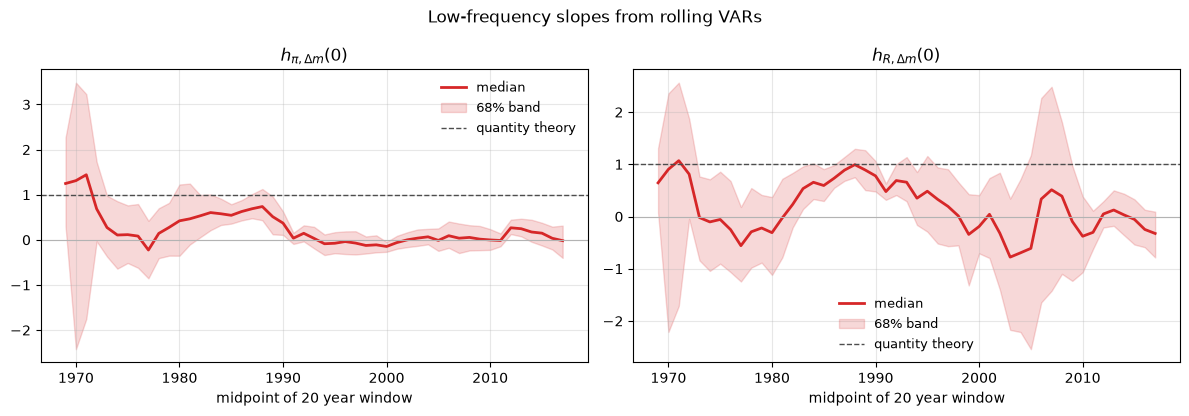

In [11]:
years = np.arange(data.index.year.min(), data.index.year.max() - 18)
mid, lo68, hi68 = {}, {}, {}
for y in years:
    m = (data.index.year >= y) & (data.index.year < y + 20)
    if m.sum() < 70:
        continue
    o = bvar_h0(data.loc[m, VARS].values, n_draws=300, seed=int(y))
    qs = np.nanpercentile(o, [16, 50, 84], axis=0)
    mid[y + 10], lo68[y + 10], hi68[y + 10] = qs[1], qs[0], qs[2]

mid = pd.DataFrame(mid).T
lo68, hi68 = pd.DataFrame(lo68).T, pd.DataFrame(hi68).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for j, (ax, ttl) in enumerate(zip(axes, [r'$h_{\pi,\Delta m}(0)$',
                                         r'$h_{R,\Delta m}(0)$'])):
    ax.plot(mid.index, mid[j], color='C3', lw=2, label='median')
    ax.fill_between(mid.index, lo68[j], hi68[j], color='C3', alpha=0.18,
                    label='68% band')
    ax.axhline(1, color='0.3', ls='--', lw=1, label='quantity theory')
    ax.axhline(0, color='0.7', lw=0.8)
    ax.set(title=ttl, xlabel='midpoint of 20 year window')
    ax.legend(frameon=False, fontsize=9)
fig.suptitle('Low-frequency slopes from rolling VARs')
plt.tight_layout()
plt.show()

这两个低频斜率在卢卡斯写作时的样本早期较高，此后逐渐向零漂移。

在 20 世纪 80 年代中期以后，其中一个几乎很少落在 68% 带之内。

这正是本讲座后文试图解释的不稳定性。

## 用于货币政策分析的模型

{cite:t}`SargentSurico2011` 第三节采用了 {cite:t}`Ireland2004` 的对数线性化黏性价格模型，其中包含价格指数化、习惯形成以及单位根技术冲击。

经济结构为

$$
\pi_t = \theta(1-\alpha_\pi) \mathbb{E}_t \pi_{t+1} + \theta \alpha_\pi \pi_{t-1}
        + \kappa x_t - \tfrac{1}{\tau} e_t ,
$$ (eq:ss_nkpc)

$$
x_t = (1-\alpha_x)\mathbb{E}_t x_{t+1} + \alpha_x x_{t-1}
      - \sigma(R_t - \mathbb{E}_t \pi_{t+1}) + \sigma(1-\xi)(1-\rho_a) a_t ,
$$ (eq:ss_is)

$$
\Delta m_t = \pi_t + z_t + \tfrac{1}{\sigma\gamma}\Delta x_t
             - \tfrac{1}{\gamma}\Delta R_t
             + \tfrac{1}{\gamma}(\Delta\chi_t - \Delta a_t) ,
$$ (eq:ss_md)

$$
\tilde y_t = x_t + \xi a_t ,
\qquad
\Delta y_t = \tilde y_t - \tilde y_{t-1} + z_t .
$$ (eq:ss_output)

这里 $\pi_t$ 是通货膨胀，$x_t$ 是产出缺口，$\Delta m_t$ 是名义货币增长，$R_t$ 是短期利率，$\tilde y_t$ 是去趋势产出，$z_t$ 是技术增长率。

方程 {eq}`eq:ss_nkpc` 是新凯恩斯菲利普斯曲线，{eq}`eq:ss_is` 是新凯恩斯 IS 曲线。

方程 {eq}`eq:ss_md` 是 {cite:t}`McCallumNelson1999` 和 {cite:t}`Ireland2003` 所提出的货币需求关系。

贴现因子为 $\theta$，$\alpha_\pi$ 是对过去通胀的指数化程度，$\alpha_x$ 是习惯形成程度，$\kappa$ 是菲利普斯曲线的斜率，$\sigma$ 是跨期替代弹性，$\tau$ 是 {cite:t}`Rotemberg1982` 的价格调整成本，$\xi$ 是弗里希弹性的倒数，$1/\gamma$ 是货币需求的利率半弹性。

有四个非政策扰动驱动经济：加成冲击 $e_t$、需求冲击 $a_t$、货币需求冲击 $\chi_t$，以及技术冲击 $z_t$，

$$
e_t = \rho_e e_{t-1} + \varepsilon_{et},
\quad
a_t = \rho_a a_{t-1} + \varepsilon_{at},
\quad
\chi_t = \rho_\chi \chi_{t-1} + \varepsilon_{\chi t},
\quad
z_t = \varepsilon_{zt} .
$$ (eq:ss_shocks)

货币政策要么是一个货币增长规则

$$
\Delta m_t = \rho_m \Delta m_{t-1} + (1-\rho_m)(\phi_\pi \pi_t + \phi_x x_t)
             + \varepsilon_{mt}
$$ (eq:ss_mrule)

要么是一个泰勒规则

$$
R_t = \rho_r R_{t-1} + (1-\rho_r)(\psi_\pi \pi_t + \psi_x x_t) + \varepsilon_{Rt} .
$$ (eq:ss_trule)

可观测变量为 $[\Delta m_t, \pi_t, R_t, \Delta y_t]$。

## 三件值得核查的事

在估计任何东西之前，先看看这一参数化设定能够提供什么、又无法提供什么，是值得的。

### $\tau$ 不可识别

价格调整成本 $\tau$ 只在一个地方进入模型，即 {eq}`eq:ss_nkpc` 中的 $e_t/\tau$ 项。

由于 $e_t$ 是一个 AR(1) 过程，其创新标准差 $\sigma_e$ 是自由估计的，因此过程 $e_t/\tau$ 是一个创新标准差为 $\sigma_e/\tau$ 的 AR(1) 过程。

因此似然函数只通过比值 $\sigma_e/\tau$ 依赖于 $(\tau, \sigma_e)$。

我们在下文用数值方法验证了这一点。

尽管如此，论文表 2 仍报告了 $\tau$ 的后验，均值为 3.51，5-95 区间为 $[1.99, 4.99]$，而先验的均值为 4，区间为 $[2.51, 5.77]$。

那个后验并不能作为关于罗滕伯格调整成本的证据。

它向左偏移，是 $\sigma_e$ 先验一旦被数据锁定比值后所隐含的结果：数据希望 $\sigma_e/\tau \approx 0.31$，而 $\sigma_e$ 的逆伽马先验均值为 $0.3$，将 $\sigma_e$ 向下拉，从而把 $\tau$ 也一并拉低。

由于 $\tau$ 没有任何实际贡献，我们将其固定在先验均值处，并少估计一个参数。

拟合结果，以及 $h(0)$，都不会因此发生任何变化。

### 当货币外生时，第一个单位斜率是一个恒等式

将货币需求方程 {eq}`eq:ss_md` 的各项归组为

$$
\Delta m_t = \pi_t + z_t + \Delta v_t ,
\qquad
v_t = \tfrac{1}{\sigma\gamma} x_t - \tfrac{1}{\gamma} R_t
      + \tfrac{1}{\gamma}(\chi_t - a_t) .
$$ (eq:ss_qtm)

除了 $\pi_t + z_t$ 之外，其余一切都是*一阶差分*。

滤波器 $1 - e^{-i\omega}$ 在 $\omega = 0$ 处消失，因此 $\Delta v_t$ 在零频率处对任何谱密度或交叉谱都没有贡献。

因此

$$
h_{\pi, \Delta m}(0)
= \frac{S_{\pi,\pi+z}(0)}{S_{\pi+z}(0)}
= 1 - \frac{S_{z,\pi+z}(0)}{S_{\pi+z}(0)} .
$$ (eq:ss_decomp)

由此可得一个命题。

```{prf:proposition}
:label: ss_prop

在货币增长规则 {eq}`eq:ss_mrule` 且 $\phi_\pi = \phi_x = 0$ 的情形下，

$$
h_{\pi, \Delta m}(0) = 1
$$

无论其他参数取何值，此式都精确成立。
```

```{prf:proof}
当 $\phi_\pi = \phi_x = 0$ 时，规则变为 $\Delta m_t = \rho_m \Delta m_{t-1} + \varepsilon_{mt}$，因此货币增长仅由 $\varepsilon_m$ 驱动。

由 {eq}`eq:ss_qtm`，$\pi_t + z_t = \Delta m_t - \Delta v_t$，而 $\Delta v$ 在零频率处没有贡献，因此 $S_{z,\pi+z}(0) = S_{z,\Delta m}(0)$。

技术是外生的，且与 $\varepsilon_m$ 正交，因此 $S_{z, \Delta m}(\omega) \equiv 0$。

现在应用 {eq}`eq:ss_decomp` 即可。
```

这一点值得深思。

卢卡斯的*第一个*例证只要货币增长在计量上是外生的就会成立，而这正是 {cite:t}`Whiteman1984` 所假设的情形。

这是货币需求设定的一个性质，而非某种深层的货币中性。

对一的偏离仅通过 $S_{z,\pi+z}(0)$ 产生，而该项只有在政策规则使得货币增长对内生变量作出反应、从而使技术在零频率处与货币增长相关时才不为零。

*第二个*例证则没有这样的支撑。

同样的论证给出 $h_{R,\Delta m}(0) = S_{R,\pi+z}(0)/S_{\pi+z}(0)$，只有当事前实际利率的低频行为恰好合作时，该值才等于一。

因此在这一结构模型内，卢卡斯的两个例证并非处于同等地位。

### 报告的 $\alpha_x$ 后验止步于一半

表 2 报告了习惯参数 $\alpha_x$ 的后验，均值为 0.4775，第 95 百分位恰好为 0.5000，先验为 $[0,1]$ 上的贝塔分布。

一个恰好止于整数的区间，通常反映的是约束而非发现。

这并非可决性约束：我们在下文核查得知，模型在 $\alpha_x = 0.5$ 两侧都存在唯一的稳定解。

因此我们让 $\alpha_x$ 遍历整个单位区间。

## 求解模型

该模型是一个线性理性预期系统，我们采用 {cite:t}`Sims2002gensys` 的方法求解。

将其写成规范形式

$$
\Gamma_0 y_t = \Gamma_1 y_{t-1} + \Psi \varepsilon_t + \Pi \eta_t ,
$$ (eq:ss_gensys)

其中 $\varepsilon_t$ 汇集了结构冲击，$\eta_t$ 汇集了预期误差，对应系统中每个出现预期的变量各有一个预期误差。

技巧在于将 $\mathbb{E}_t \pi_{t+1}$ 和 $\mathbb{E}_t x_{t+1}$ 加入变量向量，连同恒等式

$$
\pi_t = \mathbb{E}_{t-1}\pi_t + \eta^\pi_t ,
\qquad
x_t = \mathbb{E}_{t-1}x_t + \eta^x_t .
$$

求解算法对矩阵束 $(\Gamma_0, \Gamma_1)$ 进行广义舒尔分解，将稳定的广义特征值排在前面，然后判断是否可以选择预期误差以消除爆炸性的那一块。

如果可以，则存在一个稳定解；如果只能以唯一的方式选择，则该解是唯一的。

In [12]:
SMALL = 1e-6


def gensys(g0, g1, psi, pi, div=1.01):
    """
    Solve  g0 @ y[t] = g1 @ y[t-1] + psi @ eps[t] + pi @ eta[t].

    Returns (G1, impact, eu) so that, when eu == (1, 1),

        y[t] = G1 @ y[t-1] + impact @ eps[t]

    is the unique stable solution.  eu[0] flags existence, eu[1] uniqueness.
    """
    n = g0.shape[0]
    S, T, alpha, beta, Q, Z = ordqz(g0, g1, output='complex',
                                    sort=lambda a, b: abs(b) < div * abs(a))
    nunstab = int(np.sum(abs(beta) >= div * abs(alpha)))
    ns = n - nunstab
    if np.any((abs(alpha) < SMALL) & (abs(beta) < SMALL)):
        return None, None, (-2, -2)

    q = Q.conj().T
    q1, q2 = q[:ns], q[ns:]

    def trimmed_svd(M):
        u, d, vh = svd(M)
        keep = d > SMALL
        r = len(d)
        return u[:, :r][:, keep], d[keep], vh.conj().T[:, :r][:, keep]

    u2, d2, v2 = trimmed_svd(q2 @ pi)        # can eta kill the explosive block?
    u1, d1, v1 = trimmed_svd(q1 @ pi)        # is the choice unique?

    exist = len(d2) >= nunstab
    if v1.shape[1] == 0:
        unique = True
    else:
        loose = v1 - v2 @ v2.conj().T @ v1
        unique = np.sum(svd(loose, compute_uv=False) > SMALL * n) == 0
    eu = (int(exist), int(unique))
    if not exist:
        return None, None, eu

    W = u2 @ np.diag(1 / d2) @ v2.conj().T @ v1 @ np.diag(d1) @ u1.conj().T
    tmat = np.hstack([np.eye(ns), -W.conj().T])
    G0 = np.vstack([tmat @ S,
                    np.hstack([np.zeros((nunstab, ns)), np.eye(nunstab)])])
    G0i = np.linalg.inv(G0)
    G1 = np.real(Z @ (G0i @ np.vstack([tmat @ T, np.zeros((nunstab, n))]))
                 @ Z.conj().T)
    impact = np.real(Z @ (G0i @ np.vstack([tmat @ q @ psi,
                                           np.zeros((nunstab, psi.shape[1]))])))
    return G1, impact, eu

在信任它之前，我们先用一个我们可以写出解析解的模型来检验它。

在教科书式的三方程新凯恩斯模型中

$$
\pi_t = \theta \mathbb{E}_t \pi_{t+1} + \kappa x_t,
\quad
x_t = \mathbb{E}_t x_{t+1} - \sigma(R_t - \mathbb{E}_t \pi_{t+1}) + g_t,
\quad
R_t = \phi_\pi \pi_t ,
$$

其中 $g_t$ 是一个 AR(1) 过程，均衡为 $\pi_t = \pi_g g_t$ 及 $x_t = x_g g_t$，其中 $(\pi_g, x_g)$ 满足一个二乘二的线性方程组，且当且仅当 $\phi_\pi > 1$ 时均衡才唯一。

In [13]:
def toy_nk(phi_pi, theta=0.99, kappa=0.1, sigma=1.0, rho=0.8):
    """y = [pi, x, R, g, E pi(+1), E x(+1)]."""
    g0, g1 = np.zeros((6, 6)), np.zeros((6, 6))
    psi, pie = np.zeros((6, 1)), np.zeros((6, 2))
    g0[0, 0], g0[0, 4], g0[0, 1] = 1, -theta, -kappa
    g0[1, 1], g0[1, 5], g0[1, 2], g0[1, 4], g0[1, 3] = 1, -1, sigma, -sigma, -1
    g0[2, 2], g0[2, 0] = 1, -phi_pi
    g0[3, 3], g1[3, 3], psi[3, 0] = 1, rho, 1
    g0[4, 0], g1[4, 4], pie[4, 0] = 1, 1, 1
    g0[5, 1], g1[5, 5], pie[5, 1] = 1, 1, 1
    return g0, g1, psi, pie


for phi in [0.5, 1.5, 3.0]:
    G1, impact, eu = gensys(*toy_nk(phi))
    msg = 'unique stable solution' if eu == (1, 1) else 'indeterminate'
    print(f'phi_pi = {phi}:  eu = {eu}  ({msg})')

theta, kappa, sigma, rho, phi = 0.99, 0.1, 1.0, 0.8, 1.5
M = np.array([[1 - theta * rho, -kappa], [sigma * (phi - rho), 1 - rho]])
exact = np.linalg.solve(M, np.array([0.0, 1.0]))
G1, impact, _ = gensys(*toy_nk(phi))
print(f'\nanalytic (pi_g, x_g) = {np.round(exact, 8)}')
print(f'gensys   (pi_g, x_g) = {np.round(impact[:2, 0], 8)}')

phi_pi = 0.5:  eu = (1, 0)  (indeterminate)
phi_pi = 1.5:  eu = (1, 1)  (unique stable solution)
phi_pi = 3.0:  eu = (1, 1)  (unique stable solution)

analytic (pi_g, x_g) = [0.89605735 1.86379928]
gensys   (pi_g, x_g) = [0.89605735 1.86379928]


该求解器再现了解析解，精度达到机器精度，并且在 $\phi_\pi < 1$ 时正确地拒绝给出解。

## 萨金特-苏里科模型的规范形式

现在我们把方程 {eq}`eq:ss_nkpc` 到 {eq}`eq:ss_trule` 写成 {eq}`eq:ss_gensys` 的形式。

变量向量为

$$
y_t = [\pi_t,\ x_t,\ \Delta m_t,\ R_t,\ e_t,\ a_t,\ \chi_t,\ z_t,\
       \mathbb{E}_t \pi_{t+1},\ \mathbb{E}_t x_{t+1}]' ,
$$

冲击为 $\varepsilon_t = [\varepsilon_{et}, \varepsilon_{at}, \varepsilon_{\chi t}, \varepsilon_{zt}, \varepsilon_{mt}]'$。

In [14]:
PI, X, DM, R, E, A_, CH, Z, EPI, EX = range(10)
NY = 10


def canonical(p, rule='money'):
    """Matrices g0, g1, psi, pi of equations (SS-NKPC) through (SS-Taylor)."""
    th, api, kap, tau = p['theta'], p['alpha_pi'], p['kappa'], p['tau']
    ax, sig, xi, gam = p['alpha_x'], p['sigma'], p['xi'], p['gamma']
    g0, g1 = np.zeros((NY, NY)), np.zeros((NY, NY))
    psi, pie = np.zeros((NY, 5)), np.zeros((NY, 2))

    # Phillips curve
    g0[0, PI], g0[0, EPI], g0[0, X], g0[0, E] = 1, -th * (1 - api), -kap, 1 / tau
    g1[0, PI] = th * api
    # IS curve
    g0[1, X], g0[1, EX], g0[1, R], g0[1, EPI] = 1, -(1 - ax), sig, -sig
    g0[1, A_] = -sig * (1 - xi) * (1 - p['rho_a'])
    g1[1, X] = ax
    # money demand
    g0[2, DM], g0[2, PI], g0[2, Z] = 1, -1, -1
    for col, coef in [(X, -1 / (sig * gam)), (R, 1 / gam),
                      (CH, -1 / gam), (A_, 1 / gam)]:
        g0[2, col], g1[2, col] = coef, coef
    # policy rule
    if rule == 'money':
        rm = p['rho_m']
        g0[3, DM] = 1
        g0[3, PI], g0[3, X] = -(1 - rm) * p['phi_pi'], -(1 - rm) * p['phi_x']
        g1[3, DM] = rm
    else:
        rr = p['rho_r']
        g0[3, R] = 1
        g0[3, PI], g0[3, X] = -(1 - rr) * p['psi_pi'], -(1 - rr) * p['psi_x']
        g1[3, R] = rr
    psi[3, 4] = 1
    # exogenous shocks
    for row, (v, rho, k) in enumerate([(E, p['rho_e'], 0), (A_, p['rho_a'], 1),
                                       (CH, p['rho_chi'], 2), (Z, 0.0, 3)], 4):
        g0[row, v], g1[row, v], psi[row, k] = 1, rho, 1
    # expectational identities
    g0[8, PI], g1[8, EPI], pie[8, 0] = 1, 1, 1
    g0[9, X], g1[9, EX], pie[9, 1] = 1, 1, 1
    return g0, g1, psi, pie

方程 {eq}`eq:ss_output` 中的产出增长需要 $x_{t-1}$ 和 $a_{t-1}$，因此状态还要携带这两个滞后项，

$$
S_t = [y_t',\ x_{t-1},\ a_{t-1}]' ,
\qquad
S_t = A S_{t-1} + B \varepsilon_t ,
\qquad
Y_t = C S_t .
$$

这里没有测量误差，因此 $D = 0$，可以直接应用 {eq}`eq:ss_h0state`。

这里出现了一个问题。

`gensys` 的 `div` 参数用来将稳定的广义特征值与爆炸性的区分开，为了使这一区分在数值上可靠，它必须略高于一。

因此，一个被 `gensys` 报告为唯一且稳定的解，其转移矩阵仍可能存在一个恰好等于一或略高于一的根。

$h(0)$ 和卡尔曼滤波都需要协方差平稳性，因此我们显式地检验这一点，而不是仅仅信任那些标志位。

In [15]:
def state_space(p, rule='money'):
    """
    Return A, B, C for S[t] = A S[t-1] + B eps[t] and Y[t] = C S[t],
    together with a status string that is 'ok' when the equilibrium is
    unique and covariance stationary.
    """
    G1, impact, eu = gensys(*canonical(p, rule))
    if eu[0] != 1:
        return None, None, None, 'no stable solution'
    if eu[1] != 1:
        return None, None, None, 'indeterminate'
    sd = np.diag([p['sig_e'], p['sig_a'], p['sig_chi'], p['sig_z'], p['sig_m']])
    n = NY + 2
    A, B = np.zeros((n, n)), np.zeros((n, 5))
    A[:NY, :NY] = G1
    A[NY, X], A[NY + 1, A_] = 1, 1
    B[:NY] = impact @ sd
    C = np.zeros((4, n))                              # [dm, pi, R, dy]
    C[0, DM], C[1, PI], C[2, R] = 1, 1, 1
    C[3, X], C[3, NY] = 1, -1
    C[3, A_], C[3, NY + 1] = p['xi'], -p['xi']
    C[3, Z] = 1
    if np.max(np.abs(np.linalg.eigvals(A))) > 1 - 1e-9:
        return None, None, None, 'unit or explosive root'
    return A, B, C, 'ok'


def h_zero(p, rule='money'):
    """(h_pi,dm(0), h_R,dm(0)) implied by the model at parameters p."""
    A, B, C, status = state_space(p, rule)
    if status != 'ok':
        return np.nan, np.nan
    return (h_zero_from_state_space(A, B, C, 1, 0),
            h_zero_from_state_space(A, B, C, 2, 0))

这一检验很重要。

如果没有它，像 $\phi_\pi = 1$、$\phi_x = 0$ 这样的一点会返回 $h_{\pi,\Delta m}(0) = h_{R,\Delta m}(0) = 1.000$，看起来像是对卢卡斯两个例证的完美确认。

那一点处转移矩阵恰好有一个等于一的根，零频率处的谱密度并不存在，而那两个数字来自对一个条件数约为 $10^{16}$ 的矩阵求逆。

那一点正好处于论文图 6 所绘范围的右上角。

我们在下文表明，在论文自身表 2 的后验均值处，整整一条带状区域并不存在协方差平稳均衡。

现在我们可以对照论文来检验我们的实现。

在表 2 的后验均值处，{cite:t}`SargentSurico2011` 报告的蕴含值为 $h_{\pi,\Delta m}(0) = 1.0068$ 和 $h_{R,\Delta m}(0) = 0.8163$。

In [16]:
PAPER = dict(theta=0.9901, alpha_pi=0.8815, kappa=0.0324, tau=3.5126,
             alpha_x=0.4775, sigma=0.0997, xi=3.0319, gamma=3.8128,
             phi_pi=0.2312, phi_x=-0.1971, rho_m=0.7428, rho_e=0.5645,
             rho_a=0.9241, rho_chi=0.5024, sig_e=1.0922, sig_a=0.7226,
             sig_chi=0.2388, sig_z=1.5845, sig_m=1.1457)

print('h at the posterior means of Table 2: %.4f, %.4f' % h_zero(PAPER))
print('reported in Table 2:                 1.0068, 0.8163')

h at the posterior means of Table 2: 1.0093, 0.8060
reported in Table 2:                 1.0068, 0.8163


我们独立实现的结果与论文一致。

这让我们对我们理解方程 {eq}`eq:ss_nkpc` 到 {eq}`eq:ss_mrule` 的方式与作者原意相符有了信心。

### 检验这三个论断

现在我们验证前一节的三个观察。

In [17]:
print('scaling tau and sigma_e together leaves h(0) untouched:')
for f in [0.5, 1.0, 2.0, 8.0]:
    q = dict(PAPER, tau=PAPER['tau'] * f, sig_e=PAPER['sig_e'] * f)
    print(f'   tau, sigma_e scaled by {f:4.1f}:  h_pi = {h_zero(q)[0]:.10f}')

print('\nwith phi_pi = phi_x = 0, h_pi is exactly one for any other parameters:')
rng = np.random.default_rng(0)
for i in range(5):
    q = dict(PAPER, phi_pi=0.0, phi_x=0.0,
             kappa=rng.uniform(0.01, 0.3), alpha_pi=rng.uniform(0.1, 0.9),
             alpha_x=rng.uniform(0.1, 0.9), sigma=rng.uniform(0.05, 0.5),
             gamma=rng.uniform(1, 8), rho_m=rng.uniform(0, 0.95),
             sig_z=rng.uniform(0.2, 3.0), xi=rng.uniform(0.5, 5.0))
    print(f'   draw {i}:  h_pi = {h_zero(q)[0]:.12f}   h_R = {h_zero(q)[1]:.4f}')

print('\ndeterminacy on both sides of alpha_x = 0.5:')
for ax in [0.30, 0.45, 0.499, 0.501, 0.60, 0.80]:
    print(f'   alpha_x = {ax:5.3f}:  {state_space(dict(PAPER, alpha_x=ax))[3]}')

scaling tau and sigma_e together leaves h(0) untouched:
   tau, sigma_e scaled by  0.5:  h_pi = 1.0092936992
   tau, sigma_e scaled by  1.0:  h_pi = 1.0092936992
   tau, sigma_e scaled by  2.0:  h_pi = 1.0092936992
   tau, sigma_e scaled by  8.0:  h_pi = 1.0092936992

with phi_pi = phi_x = 0, h_pi is exactly one for any other parameters:
   draw 0:  h_pi = 1.000000000000   h_R = 0.4849
   draw 1:  h_pi = 1.000000000000   h_R = -0.0141
   draw 2:  h_pi = 1.000000000000   h_R = 0.2936
   draw 3:  h_pi = 1.000000000000   h_R = 0.7060
   draw 4:  h_pi = 1.000000000000   h_R = 0.7182

determinacy on both sides of alpha_x = 0.5:
   alpha_x = 0.300:  ok
   alpha_x = 0.450:  ok
   alpha_x = 0.499:  ok
   alpha_x = 0.501:  ok
   alpha_x = 0.600:  ok
   alpha_x = 0.800:  ok


三个论断都成立。

似然函数在 $(\tau, \sigma_e)$ 的缩放变换下保持不变，第一个单位斜率在货币增长外生时是一个恒等式，且模型在 $\alpha_x = 1/2$ 两侧都是可决的。

还要注意，$h_{R,\Delta m}(0)$ 在这些相同的抽样中变化很大，这正是 {prf:ref}`ss_prop` 所预测的两个例证之间的不对称性。

最后，这里是图 6 所示政策网格中的一条带状区域，在论文自身的后验均值处，该区域不存在协方差平稳均衡。

In [18]:
for phi_x in [0.0, -0.25, -0.5]:
    bad = [round(g, 2) for g in np.linspace(-3, 1, 41)
           if state_space(dict(PAPER, phi_pi=g, phi_x=phi_x))[3] != 'ok']
    print(f'phi_x = {phi_x:5.2f}: no stationary equilibrium at phi_pi in '
          f'{bad if bad else "none of the grid"}')

phi_x =  0.00: no stationary equilibrium at phi_pi in [np.float64(-3.0), np.float64(-2.9), np.float64(-2.8), np.float64(-2.7), np.float64(-2.6), np.float64(-2.5), np.float64(-2.4), np.float64(-2.3), np.float64(-2.2), np.float64(-2.1), np.float64(-2.0), np.float64(-1.9), np.float64(-1.8), np.float64(-1.7), np.float64(-1.6), np.float64(1.0)]
phi_x = -0.25: no stationary equilibrium at phi_pi in none of the grid
phi_x = -0.50: no stationary equilibrium at phi_pi in none of the grid


该带状区域远离估计出的政策规则，因此论文的结论并不受此影响。

但如果在该区域上报告 $h(0)$，那将是从一个并不存在的谱密度中计算出来的数字。

## 贝叶斯估计

我们在论文所用样本 1960:I-1983:IV 上估计货币增长规则版本。

四个可观测变量已去均值化，因为模型是以偏离稳态的形式写出的。

In [19]:
mask = (data.index.year >= 1960) & (data.index.year <= 1983)
Y_est = data.loc[mask, VARS].values
Y_est = Y_est - Y_est.mean(0)
print(f'estimation sample: {mask.sum()} quarters, '
      f'{data.index[mask][0].date()} to {data.index[mask][-1].date()}')

estimation sample: 96 quarters, 1960-01-01 to 1983-10-01


### 似然函数

给定 $(A, B, C)$，似然函数可由卡尔曼滤波得出。

我们将状态初始化在其无条件均值和协方差处，后者通过求解离散李雅普诺夫方程 $P = A P A' + BB'$ 得到。

In [20]:
def loglik(p, Y, rule='money'):
    """Kalman filter log likelihood of Y (T x 4) at parameters p."""
    A, B, C, status = state_space(p, rule)
    if status != 'ok':
        return -np.inf
    Q = B @ B.T
    try:
        P = solve_discrete_lyapunov(A, Q)
    except Exception:
        return -np.inf
    s = np.zeros(A.shape[0])
    ll, const = 0.0, Y.shape[1] * np.log(2 * np.pi)
    for t in range(Y.shape[0]):
        s = A @ s
        P = A @ P @ A.T + Q
        v = Y[t] - C @ s                              # forecast error
        PCt = P @ C.T
        F = C @ PCt                                   # its covariance
        try:
            L = np.linalg.cholesky(F)
        except np.linalg.LinAlgError:
            return -np.inf
        u = np.linalg.solve(L, v)
        ll -= 0.5 * (const + 2 * np.sum(np.log(np.diag(L))) + u @ u)
        K = np.linalg.solve(F, PCt.T).T               # Kalman gain
        s, P = s + K @ v, P - K @ PCt.T
    return ll if np.isfinite(ll) else -np.inf

### 先验

我们使用表 2 的先验均值和标准差，通过矩匹配来选定每个分布族的参数。

In [21]:
def beta_prior(m, s):
    nu = m * (1 - m) / s ** 2 - 1
    return stats.beta(m * nu, (1 - m) * nu)


def gamma_prior(m, s):
    return stats.gamma(m ** 2 / s ** 2, scale=s ** 2 / m)


def invgamma_prior(m, s):
    a = m ** 2 / s ** 2 + 2
    return stats.invgamma(a, scale=m * (a - 1))


PRIOR, SUPPORT = {}, {}
for n, (m, s) in [('theta', (0.99, 0.005)), ('alpha_pi', (0.5, 0.2)),
                  ('alpha_x', (0.5, 0.2)), ('rho_m', (0.5, 0.05)),
                  ('rho_e', (0.5, 0.1)), ('rho_a', (0.5, 0.1)),
                  ('rho_chi', (0.5, 0.1))]:
    PRIOR[n], SUPPORT[n] = beta_prior(m, s), (1e-6, 1 - 1e-6)
for n, (m, s) in [('kappa', (0.3, 0.1)), ('sigma', (0.1, 0.05)),
                  ('xi', (2.0, 1.0)), ('gamma', (4.0, 1.0))]:
    PRIOR[n], SUPPORT[n] = gamma_prior(m, s), (1e-8, np.inf)
for n in ['phi_pi', 'phi_x']:
    PRIOR[n], SUPPORT[n] = stats.norm(0, 0.5), (-np.inf, np.inf)
for n in ['sig_e', 'sig_a', 'sig_chi', 'sig_z', 'sig_m']:
    PRIOR[n], SUPPORT[n] = invgamma_prior(0.3, 1.0), (1e-8, np.inf)

FREE = ['theta', 'alpha_pi', 'kappa', 'alpha_x', 'sigma', 'xi', 'gamma',
        'phi_pi', 'phi_x', 'rho_m', 'rho_e', 'rho_a', 'rho_chi',
        'sig_e', 'sig_a', 'sig_chi', 'sig_z', 'sig_m']
TAU = 4.0                       # not identified; fixed at its prior mean


def unpack(v):
    return dict({n: float(x) for n, x in zip(FREE, v)}, tau=TAU)


def log_post(v, Y):
    lp = 0.0
    for n, x in zip(FREE, v):
        lo, hi = SUPPORT[n]
        if not lo < x < hi:
            return -np.inf
        lp += PRIOR[n].logpdf(x)
    return lp + loglik(unpack(v), Y)

### 后验众数

我们从论文的后验均值开始搜索，使用鲍威尔的无导数方法，并用梯度方法进行精修。

In [22]:
v_start = np.array([PAPER[n] for n in FREE])
neg_log_post = lambda v: -log_post(v, Y_est)

res = optimize.minimize(neg_log_post, v_start, method='Powell',
                        options=dict(maxiter=20000, maxfev=20000))
res = optimize.minimize(neg_log_post, res.x, method='L-BFGS-B',
                        bounds=[SUPPORT[n] for n in FREE])
v_mode = res.x
print(f'log posterior at the paper\'s means: {log_post(v_start, Y_est):10.3f}')
print(f'log posterior at the mode:          {-res.fun:10.3f}')
print('h(0) at the mode: %.4f, %.4f' % h_zero(unpack(v_mode)))

log posterior at the paper's means:   -531.052
log posterior at the mode:            -320.204
h(0) at the mode: 0.9764, 0.7696


```{note}
从论文的估计值开始搜索，会找到离它们最近的那个众数。

本讲座末尾的哈密顿蒙特卡洛部分会发现，这只是一个*局部*众数，而后验存在另一个密度更高的众数。
```

### 随机游走 Metropolis-Hastings

标准的提议协方差是在众数处对负对数后验求逆黑塞矩阵，我们用有限差分法计算它。

In [23]:
def numerical_hessian(f, v, rel=1e-4):
    n = len(v)
    h = rel * np.maximum(np.abs(v), 1e-2)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i], ej[j] = h[i], h[j]
            H[i, j] = H[j, i] = (f(v + ei + ej) - f(v + ei - ej)
                                 - f(v - ei + ej) + f(v - ei - ej)) / (4 * h[i] * h[j])
    return H


H = numerical_hessian(neg_log_post, v_mode)
Sigma_prop = np.linalg.inv(H)
print('proposal covariance is positive definite:',
      np.all(np.linalg.eigvalsh(H) > 0))

proposal covariance is positive definite: True


In [24]:
def rwmh(Y, v0, Sigma, n_draws, c=0.45, seed=42):
    """Random walk Metropolis-Hastings in the natural parameter space."""
    rng = np.random.default_rng(seed)
    L = np.linalg.cholesky(Sigma)
    v, lp = v0.copy(), log_post(v0, Y)
    draws, n_acc = np.empty((n_draws, len(v))), 0
    for i in range(n_draws):
        cand = v + c * (L @ rng.standard_normal(len(v)))
        lp_cand = log_post(cand, Y)
        if np.log(rng.random()) < lp_cand - lp:
            v, lp, n_acc = cand, lp_cand, n_acc + 1
        draws[i] = v
    return draws, n_acc / n_draws

落在先验支撑之外的抽样会被赋予 $-\infty$ 并被拒绝，因此我们可以直接在自然参数空间中工作，而无需进行变换。

下面的链足够短，可以让你一边阅读一边运行；真正认真的应用需要更多的抽样。

In [25]:
N_DRAWS, BURN = 30_000, 10_000

t0 = time.time()
draws, acc_rate = rwmh(Y_est, v_mode, Sigma_prop, N_DRAWS)
rwmh_seconds = time.time() - t0

kept = draws[BURN::5]
print(f'acceptance rate {acc_rate:.3f},  {len(kept)} retained draws, '
      f'{rwmh_seconds:.0f} seconds')

acceptance rate 0.278,  4000 retained draws, 186 seconds


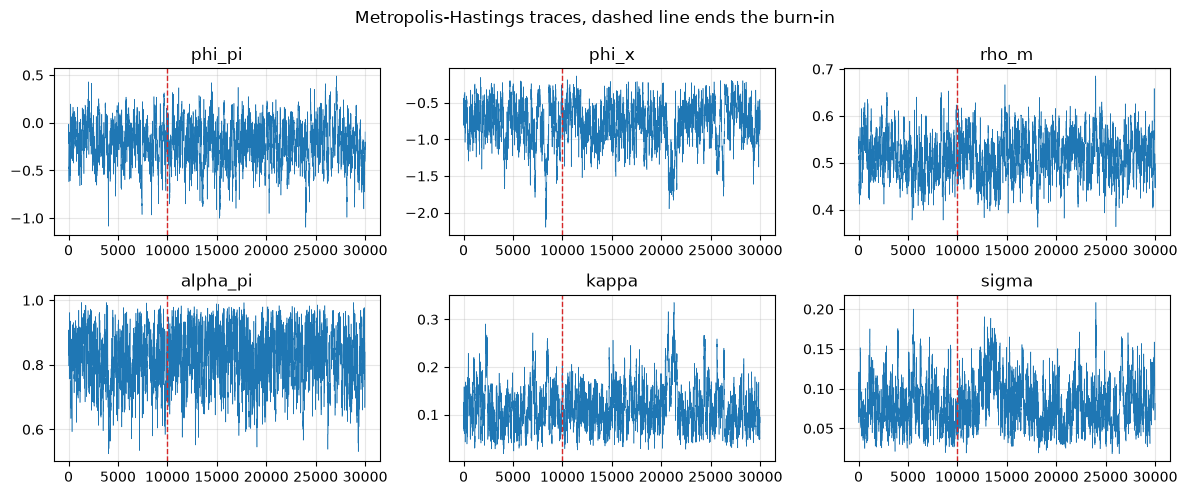

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for ax, n in zip(axes.flat, ['phi_pi', 'phi_x', 'rho_m',
                             'alpha_pi', 'kappa', 'sigma']):
    j = FREE.index(n)
    ax.plot(draws[:, j], lw=0.4, color='C0')
    ax.axvline(BURN, color='C3', ls='--', lw=1)
    ax.set_title(n)
fig.suptitle('Metropolis-Hastings traces, dashed line ends the burn-in')
plt.tight_layout()
plt.show()

In [27]:
summary = pd.DataFrame({
    'prior mean': [PRIOR[n].mean() for n in FREE],
    'post. mean': kept.mean(0),
    '5th': np.percentile(kept, 5, axis=0),
    '95th': np.percentile(kept, 95, axis=0),
    'paper': [PAPER[n] for n in FREE]}, index=FREE)
summary.round(4)

,prior mean,post. mean,5th,95th,paper
theta,0.99,0.9890,0.9797,0.9961,0.9901
alpha_pi,0.50,0.8233,0.6783,0.9458,0.8815
kappa,0.30,0.1167,0.0539,0.2031,0.0324
alpha_x,0.50,0.3793,0.2983,0.4305,0.4775
sigma,0.10,0.0828,0.0384,0.1420,0.0997
xi,2.00,3.4819,2.0043,5.5033,3.0319
gamma,4.00,2.0509,1.5959,2.5512,3.8128
phi_pi,0.00,-0.2262,-0.6035,0.1302,0.2312
phi_x,0.00,-0.7882,-1.3476,-0.3586,-0.1971
rho_m,0.50,0.5164,0.4428,0.5878,0.7428


我们的估计值明显与表 2 的相符，其差异也是不同利率序列和不同数据版本所应产生的差异。

菲利普斯曲线具有强烈的向后看性质且斜率平缓，IS 曲线则远没有那么强的向后看性质。

对下文而言最重要的是，货币增长规则对通货膨胀的反应很弱，$\phi_\pi$ 的后验横跨零点，并且带有相当程度的平滑。

这正是论文对 1984 年前政体的核心解读：美联储将持续的、近乎外生的波动注入到货币增长之中。

由 {prf:ref}`ss_prop` 可知，这正是卢卡斯第一个例证成立的那种配置，这也正是为什么论文自己在表 2 中对 $h_{\pi,\Delta m}(0)$ 的后验会如此紧密地围绕一。

### $h(0)$ 的后验分布

结构参数的每一次抽样都蕴含一对低频斜率。

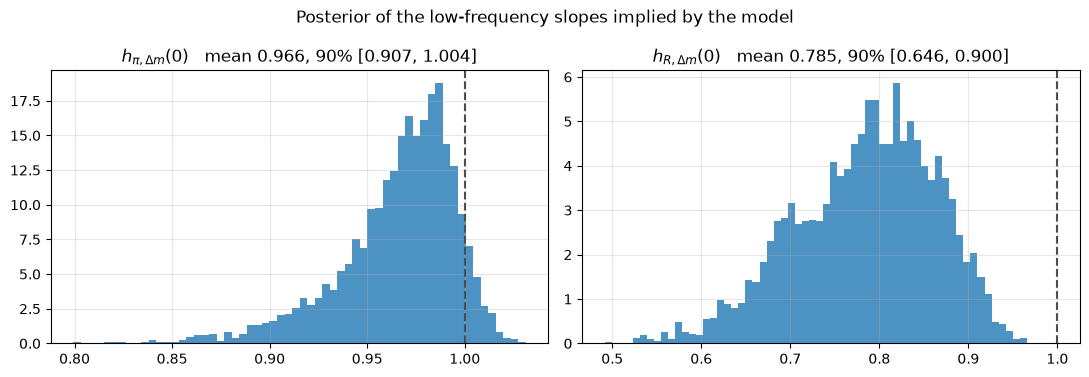

In [28]:
h_draws = np.array([h_zero(unpack(v)) for v in kept])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, j, ttl in zip(axes, [0, 1],
                      [r'$h_{\pi,\Delta m}(0)$', r'$h_{R,\Delta m}(0)$']):
    ax.hist(h_draws[:, j], bins=60, color='C0', alpha=0.8, density=True)
    ax.axvline(1, color='0.3', ls='--', lw=1.5)
    ax.set_title(f'{ttl}   mean {h_draws[:, j].mean():.3f}, '
                 f'90% [{np.percentile(h_draws[:, j], 5):.3f}, '
                 f'{np.percentile(h_draws[:, j], 95):.3f}]')
fig.suptitle('Posterior of the low-frequency slopes implied by the model')
plt.tight_layout()
plt.show()

估计出的模型在一个非常接近卢卡斯所用样本的样本上，重现了他的两个例证。

将这些结果与我们前面计算得到的 1960-1983 年 VAR 估计值，以及论文报告的后验均值 1.0068 和 0.8163 相比较。

## 货币政策如何移动低频斜率

现在来看论文的主要实验。

我们将每个结构参数锁定在其后验均值处，只改变两个政策系数，并在每一点上重新计算 $h(0)$。

In [29]:
p_bar = unpack(kept.mean(0))


def h_grid(p, rule, k1, k2, g1_vals, g2_vals):
    H1 = np.full((len(g2_vals), len(g1_vals)), np.nan)
    H2 = np.full_like(H1, np.nan)
    for i, b in enumerate(g2_vals):
        for j, a in enumerate(g1_vals):
            H1[i, j], H2[i, j] = h_zero(dict(p, **{k1: a, k2: b}), rule)
    return H1, H2


phi_pi_grid = np.linspace(-3, 1, 49)
phi_x_grid = np.linspace(-1, 0, 25)
Hpi, HR = h_grid(p_bar, 'money', 'phi_pi', 'phi_x', phi_pi_grid, phi_x_grid)

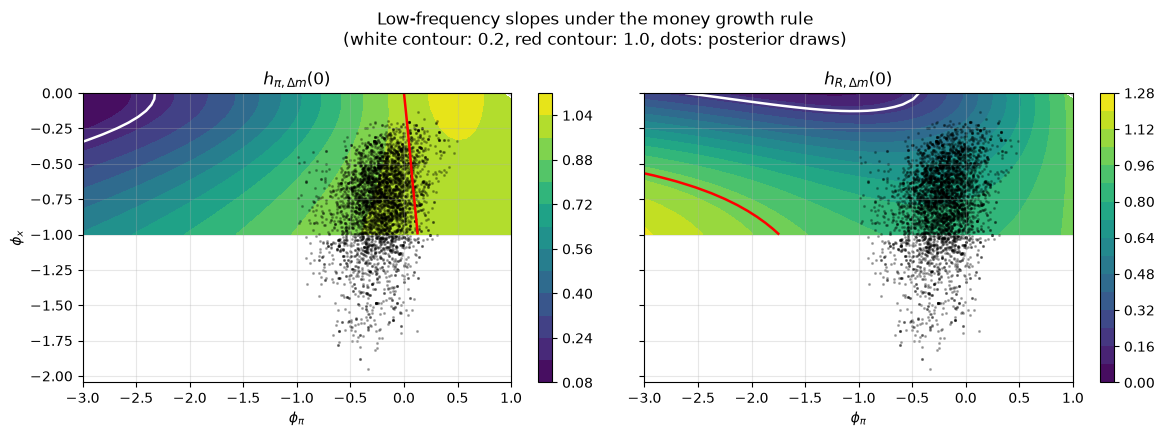

In [30]:
def contour_panel(g1_vals, g2_vals, H1, H2, xlab, ylab, suptitle, scatter=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
    for ax, Hm, ttl in zip(axes, [H1, H2],
                           [r'$h_{\pi,\Delta m}(0)$', r'$h_{R,\Delta m}(0)$']):
        cs = ax.contourf(g1_vals, g2_vals, Hm, levels=14, cmap='viridis')
        ax.contour(g1_vals, g2_vals, Hm, levels=[0.2, 1.0],
                   colors=['white', 'red'], linewidths=1.8)
        ax.contourf(g1_vals, g2_vals, np.isnan(Hm).astype(float),
                    levels=[0.5, 1.5], colors=['0.85'])
        if scatter is not None:
            ax.scatter(*scatter, s=1.5, color='k', alpha=0.25)
        fig.colorbar(cs, ax=ax)
        ax.set(title=ttl, xlabel=xlab)
    axes[0].set_ylabel(ylab)
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


contour_panel(phi_pi_grid, phi_x_grid, Hpi, HR, r'$\phi_\pi$', r'$\phi_x$',
              'Low-frequency slopes under the money growth rule\n'
              '(white contour: 0.2, red contour: 1.0, dots: posterior draws)',
              scatter=(kept[:, FREE.index('phi_pi')],
                       kept[:, FREE.index('phi_x')]))

有三点浮现出来，它们正是论文的三个发现。

低频斜率*并非*政策不变的：仅仅移动 $(\phi_\pi, \phi_x)$ 就能使 $h_{\pi,\Delta m}(0)$ 扫过滚动 VAR 所显示范围的大部分。

后验抽样的点云聚集在两个斜率都接近一的区域，这正是 1960-1983 年数据所处的位置。

而更加激进的抗通胀立场，即较大的*负*的 $\phi_\pi$（意味着当通胀上升时货币增长被大力削减），会使两个斜率都远远低于一，最小值出现在 $\phi_x$ 也接近零的那个角落。

红色等高线标出了 $h(0) = 1$ 的位置，正如 {prf:ref}`ss_prop` 所要求的那样，它恰好穿过 $\phi_\pi = \phi_x = 0$ 这一点。

任何灰色区域都对应着不存在唯一协方差平稳均衡、$h(0)$ 不存在的情形。

以下是斜率触底的位置、在政策系数 $\phi_x$ 后验均值处的一个网格切片，以及平稳性检验剔除掉的网格比例。

In [31]:
print(f'no stationary equilibrium at {np.isnan(Hpi).mean():.0%} of grid points')
for name, Hm in [('h_pi', Hpi), ('h_R', HR)]:
    i, j = np.unravel_index(np.nanargmin(Hm), Hm.shape)
    print(f'   smallest {name:5s} = {Hm[i, j]:6.3f} at '
          f'phi_pi = {phi_pi_grid[j]:5.2f}, phi_x = {phi_x_grid[i]:5.2f}')

row = np.argmin(np.abs(phi_x_grid - p_bar['phi_x']))
print(f'\nslice at phi_x = {phi_x_grid[row]:.3f}')
for j in range(0, len(phi_pi_grid), 6):
    print(f'   phi_pi = {phi_pi_grid[j]:6.2f}:  '
          f'h_pi = {Hpi[row, j]:7.3f},  h_R = {HR[row, j]:7.3f}')

no stationary equilibrium at 0% of grid points
   smallest h_pi  =  0.095 at phi_pi = -3.00, phi_x =  0.00
   smallest h_R   =  0.058 at phi_pi = -1.25, phi_x =  0.00

slice at phi_x = -0.792
   phi_pi =  -3.00:  h_pi =   0.465,  h_R =   1.143
   phi_pi =  -2.50:  h_pi =   0.552,  h_R =   1.062
   phi_pi =  -2.00:  h_pi =   0.648,  h_R =   0.977
   phi_pi =  -1.50:  h_pi =   0.750,  h_R =   0.897
   phi_pi =  -1.00:  h_pi =   0.848,  h_R =   0.833
   phi_pi =  -0.50:  h_pi =   0.933,  h_R =   0.799
   phi_pi =   0.00:  h_pi =   0.992,  h_R =   0.810
   phi_pi =   0.50:  h_pi =   1.017,  h_R =   0.872
   phi_pi =   1.00:  h_pi =   1.005,  h_R =   0.980


### 用泰勒规则重复同样的练习

论文用利率规则 {eq}`eq:ss_trule` 重复了这一实验。

我们将平滑系数和政策冲击标准差固定在货币规则的估计值处，改变 $(\psi_\pi, \psi_x)$。

在泰勒规则使均衡不可决的地方，我们只是将其记录下来，并将这些区域涂成灰色；论文则选用了 {cite:t}`LubikSchorfheide2004` 的正交解。

indeterminate or nonexistent at 33% of grid points
h_pi ranges over [0.69, 1.00]
h_R  ranges over [0.89, 1.87]


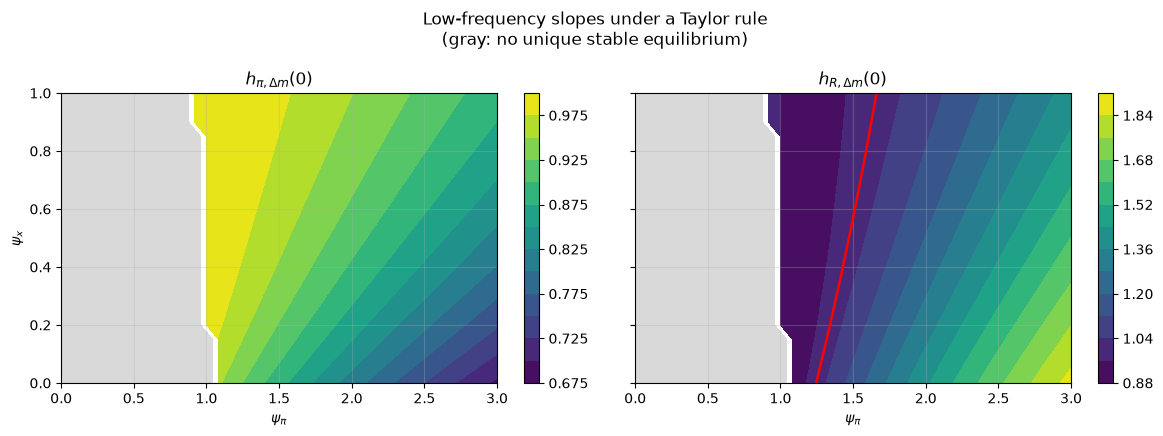

In [32]:
p_taylor = dict(p_bar, rho_r=p_bar['rho_m'], psi_pi=1.5, psi_x=0.5)
psi_pi_grid = np.linspace(0, 3, 37)
psi_x_grid = np.linspace(0, 1, 21)
Tpi, TR = h_grid(p_taylor, 'taylor', 'psi_pi', 'psi_x',
                 psi_pi_grid, psi_x_grid)

print(f'indeterminate or nonexistent at {np.isnan(Tpi).mean():.0%} of grid points')
print(f'h_pi ranges over [{np.nanmin(Tpi):.2f}, {np.nanmax(Tpi):.2f}]')
print(f'h_R  ranges over [{np.nanmin(TR):.2f}, {np.nanmax(TR):.2f}]')

contour_panel(psi_pi_grid, psi_x_grid, Tpi, TR, r'$\psi_\pi$', r'$\psi_x$',
              'Low-frequency slopes under a Taylor rule\n'
              '(gray: no unique stable equilibrium)')

对政策的依赖依然存在，但要弱得多。

在可决区域内，泰勒规则无法将任一斜率驱动到接近零的水平。

这正是论文发现的利率规则"较难复现估计结果"的地方。

分解式 {eq}`eq:ss_decomp` 提供了一个原因。

要将 $h_{\pi,\Delta m}(0)$ 推向零，需要使比值 $S_{z,\pi+z}(0)/S_{\pi+z}(0)$ 接近一，实际上这意味着挤压通货膨胀的零频率功率，直到 $\pi_t + z_t$ 被技术所主导。

一个带有很大负 $\phi_\pi$ 的货币增长规则恰恰能做到这一点，因为中央银行是在直接选择 {eq}`eq:ss_qtm` 的左边。

而泰勒规则则是设定利率，让货币增长由货币需求决定，因此它对通货膨胀相对于货币增长的低频行为几乎没有掌控力，$h_{\pi,\Delta m}(0)$ 就一直停留在接近一的水平。

## 用哈密顿蒙特卡洛进行估计

产生我们后验的随机游走采样器，是 DSGE 估计的传统主力方法。

它也是低效的，而我们可以衡量这种低效程度。

本节将萨金特-苏里科模型用作现代替代方法的实验样本。

### 随机游走给出了什么

一条长度为 $N$ 的相关链所蕴含的信息量，少于 $N$ 个独立抽样，**有效样本量**给出了具体是多少。

In [33]:
import arviz as az

rwmh_idata = az.from_dict(
    {'posterior': {n: kept[:, j][None, :] for j, n in enumerate(FREE)}})
rwmh_summary = az.summary(rwmh_idata, var_names=FREE)
print(rwmh_summary[['mean', 'sd', 'ess_bulk']].to_string())
print(f'\n{len(kept)} retained draws out of {N_DRAWS}, in {rwmh_seconds:.0f} seconds')
print(f'smallest effective sample size = {rwmh_summary["ess_bulk"].min():.0f}')

           mean     sd ess_bulk
theta     0.989  0.005      294
alpha_pi  0.823  0.081      341
kappa      0.12   0.05       90
alpha_x    0.38   0.04       26
sigma     0.083  0.031       44
xi          3.5    1.1       62
gamma      2.05   0.29       75
phi_pi    -0.23   0.22      278
phi_x     -0.79    0.3       61
rho_m     0.516  0.044      237
rho_e     0.245  0.063      274
rho_a      0.84   0.06       25
rho_chi    0.51  0.094      270
sig_e      1.18   0.16      193
sig_a      0.26   0.08       75
sig_chi    0.14  0.068      163
sig_z      0.71   0.12       32
sig_m      0.71   0.06       44

4000 retained draws out of 30000, in 186 seconds
smallest effective sample size = 26


数万次迭代大约只能为混合最差的参数换来一百个左右的独立抽样。

原因体现在提议分布上。

随机游走在全部十八个参数的方向上进行扰动，而这个方向对后验的局部形状一无所知，因此步长必须迁就最受约束的方向，而最松弛的方向也只能以同样缓慢的速度被探索。

我们的后验尺度很差。

In [34]:
w = np.linalg.eigvalsh(H)
print(f'condition number of the posterior Hessian     {w.max() / w.min():10.3g}')
print(f'ratio of longest to shortest posterior scale  {np.sqrt(w.max() / w.min()):10.0f}')

condition number of the posterior Hessian       4.07e+04
ratio of longest to shortest posterior scale         202


### 为什么哈密顿方法对 DSGE 模型来说很棘手

**哈密顿蒙特卡洛** {cite}`DuaneEtAl1987,Neal2011` 将参数向量视为一个粒子的位置，赋予它一个随机的动量，并模拟哈密顿动力学，其中负对数后验扮演势能的角色。

轨迹沿着分布的等高线移动，而不是横冲直撞地穿过它们，因此一个提议可以移动很长的距离，同时仍被接受。

**无掉头采样器** {cite}`HoffmanGelman2014` 消除了对轨迹长度进行调优的需要，它将每条轨迹延伸，直到它开始向回折返为止。

{cite:t}`Betancourt2017` 给出了一个概念性的介绍。

代价是需要梯度 $\nabla_\theta \log p(\theta \mid Y)$。

这正是 DSGE 模型变得棘手的地方。

我们的似然函数要经过 `gensys`，其第一个动作是一次*排序*的广义舒尔分解：它计算广义特征值，按模**排序**，并重新排列分解以与之匹配。

排序是一个离散操作，而没有哪个自动微分库能够通过它传播导数。

正是这一点，而不是任何统计上的反对意见，才是哈密顿方法在 DSGE 估计中仍不常见的原因。

### 一个可微的求解器

障碍在于*算法*，而不在于模型本身，因此我们更换算法。

将均衡条件写为

$$
F_A\, \mathbb{E}_t y_{t+1} + F_B\, y_t + F_C\, y_{t-1} + F_E\, \varepsilon_t = 0 ,
$$ (eq:ss_structural)

其中

$$
y_t = [\pi_t,\ x_t,\ \Delta m_t,\ R_t,\ e_t,\ a_t,\ \chi_t,\ z_t,\ u_t]'
$$

且 $u_t = \varepsilon_{mt}$ 携带货币规则冲击。

`gensys` 所需要的辅助预期变量在这里并不需要。

假设一个解的形式为

$$
y_t = G\, y_{t-1} + \Theta\, \varepsilon_t .
$$ (eq:ss_conjecture)

那么 $\mathbb{E}_t y_{t+1} = G y_t$，方程 {eq}`eq:ss_structural` 变为

$$
(F_A G + F_B)\, y_t + F_C\, y_{t-1} + F_E\, \varepsilon_t = 0 .
$$

求解出 $y_t$ 并与 {eq}`eq:ss_conjecture` 匹配系数，得到一个只含 $G$ 的不动点，

$$
G = -(F_A G + F_B)^{-1} F_C ,
\qquad
\Theta = -(F_A G + F_B)^{-1} F_E .
$$ (eq:ss_fixedpoint)

从 $G = 0$ 开始迭代 {eq}`eq:ss_fixedpoint`，其中只涉及矩阵乘积和线性求解，每一步都是可微的。

In [35]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax import lax
from numpyro.infer import MCMC, NUTS

jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

U, NJ = 8, 9          # y = [pi, x, dm, R, e, a, chi, z, u]


def structural(p):
    """Return F_A, F_B, F_C, F_E of equation (SS-structural)."""
    th, api, kap = p['theta'], p['alpha_pi'], p['kappa']
    ax, sig, xi, gam = p['alpha_x'], p['sigma'], p['xi'], p['gamma']
    rm, ra = p['rho_m'], p['rho_a']
    FA = jnp.zeros((NJ, NJ)); FB = jnp.zeros((NJ, NJ))
    FC = jnp.zeros((NJ, NJ)); FE = jnp.zeros((NJ, 5))

    FA = FA.at[0, PI].set(-th * (1 - api))                        # Phillips curve
    FB = FB.at[0, PI].set(1).at[0, X].set(-kap).at[0, E].set(1 / TAU)
    FC = FC.at[0, PI].set(-th * api)

    FA = FA.at[1, X].set(-(1 - ax)).at[1, PI].set(-sig)           # IS curve
    FB = (FB.at[1, X].set(1).at[1, R].set(sig)
            .at[1, A_].set(-sig * (1 - xi) * (1 - ra)))
    FC = FC.at[1, X].set(-ax)

    FB = FB.at[2, DM].set(1).at[2, PI].set(-1).at[2, Z].set(-1)   # money demand
    FB = (FB.at[2, X].set(-1 / (sig * gam)).at[2, R].set(1 / gam)
            .at[2, CH].set(-1 / gam).at[2, A_].set(1 / gam))
    FC = (FC.at[2, X].set(1 / (sig * gam)).at[2, R].set(-1 / gam)
            .at[2, CH].set(1 / gam).at[2, A_].set(-1 / gam))

    FB = (FB.at[3, DM].set(1).at[3, U].set(-1)                    # policy rule
            .at[3, PI].set(-(1 - rm) * p['phi_pi'])
            .at[3, X].set(-(1 - rm) * p['phi_x']))
    FC = FC.at[3, DM].set(-rm)

    for row, (v, rho, k) in enumerate([(E, p['rho_e'], 0), (A_, ra, 1),
                                       (CH, p['rho_chi'], 2), (Z, 0.0, 3)], 4):
        FB = FB.at[row, v].set(1)
        FC = FC.at[row, v].set(-rho)
        FE = FE.at[row, k].set(-1)
    FB = FB.at[8, U].set(1)
    FE = FE.at[8, 4].set(-1)
    return FA, FB, FC, FE


def solve_fixed_point(p, n_iter=60):
    """Iterate (SS-fixedpoint) to convergence; differentiable throughout."""
    FA, FB, FC, FE = structural(p)

    def step(G, _):
        return -jnp.linalg.solve(FA @ G + FB, FC), None

    G, _ = lax.scan(step, jnp.zeros((NJ, NJ)), None, length=n_iter)
    return G, -jnp.linalg.solve(FA @ G + FB, FE)

在信任它之前，我们在论文的后验均值处将其与 `gensys` 进行核对。

这两个算法没有共享任何代码，因此在机器精度上的一致性是一个真正的检验。

In [36]:
p_check = {n: float(PAPER[n]) for n in FREE}
G_fp, Theta_fp = solve_fixed_point(p_check)

A_gen, B_gen, C_gen, _ = state_space(dict(p_check, tau=TAU))
idx = [PI, X, DM, R, E, A_, CH, Z]
sd_check = np.array([p_check[n] for n in
                     ['sig_e', 'sig_a', 'sig_chi', 'sig_z', 'sig_m']])

print('fixed point versus gensys')
print(f'   transition matrix  max abs difference  '
      f'{np.abs(np.asarray(G_fp)[np.ix_(idx, idx)] - A_gen[:10, :10][np.ix_(idx, idx)]).max():.2e}')
print(f'   shock loadings     max abs difference  '
      f'{np.abs(np.asarray(Theta_fp * sd_check)[idx] - B_gen[:10][idx]).max():.2e}')

fixed point versus gensys
   transition matrix  max abs difference  3.20e-15
   shock loadings     max abs difference  7.77e-16


```{note}
当存在稳定解时，不动点会收敛到该稳定解，但与 `gensys` 不同，它不会返回存在性和唯一性的标志。

因此，我们在上一节的可决性图中保留使用 `gensys`，只在需要求导的地方使用不动点方法。
```

### JAX 中的似然函数

卡尔曼滤波保持不变地照搬过来，用 `lax.scan` 来编写，以便它也能够被求导。

唯一实质性的变化是初始协方差：我们不再调用一个李雅普诺夫求解器，而是使用 $\operatorname{vec}(P) = (I - A \otimes A)^{-1}\operatorname{vec}(Q)$，这只是一次线性求解。

In [37]:
def state_space_jax(p):
    G, Theta = solve_fixed_point(p)
    sd = jnp.array([p['sig_e'], p['sig_a'], p['sig_chi'], p['sig_z'], p['sig_m']])
    n = NJ + 2                                   # append x(-1) and a(-1)
    A = jnp.zeros((n, n)).at[:NJ, :NJ].set(G)
    A = A.at[NJ, X].set(1).at[NJ + 1, A_].set(1)
    B = jnp.zeros((n, 5)).at[:NJ].set(Theta * sd)
    C = jnp.zeros((4, n))
    C = C.at[0, DM].set(1).at[1, PI].set(1).at[2, R].set(1)
    C = C.at[3, X].set(1).at[3, NJ].set(-1)
    C = C.at[3, A_].set(p['xi']).at[3, NJ + 1].set(-p['xi'])
    C = C.at[3, Z].set(1)
    return A, B, C


def loglik_jax(p, Y):
    A, B, C = state_space_jax(p)
    n = A.shape[0]
    Q = B @ B.T
    P0 = jnp.linalg.solve(jnp.eye(n * n) - jnp.kron(A, A),
                          Q.reshape(-1)).reshape(n, n)
    const = Y.shape[1] * jnp.log(2 * jnp.pi)

    def step(carry, y):
        s, P = carry
        s, P = A @ s, A @ P @ A.T + Q
        v = y - C @ s
        PCt = P @ C.T
        F = C @ PCt
        L = jnp.linalg.cholesky(F)
        u = jax.scipy.linalg.solve_triangular(L, v, lower=True)
        ll = -0.5 * (const + 2 * jnp.sum(jnp.log(jnp.diag(L))) + u @ u)
        K = jnp.linalg.solve(F, PCt.T).T
        return (s + K @ v, P - K @ PCt.T), ll

    _, lls = lax.scan(step, (jnp.zeros(n), P0), Y)
    return jnp.sum(lls)

两项检查：新的似然函数必须与我们用于随机游走的那个一致，其梯度必须与有限差分一致。

In [38]:
Y_jax = jnp.asarray(Y_est)
print(f'log likelihood, JAX    {float(loglik_jax(p_check, Y_jax)):.8f}')
print(f'log likelihood, NumPy  {loglik(dict(p_check, tau=TAU), Y_est):.8f}')

grad_ll = jax.jit(jax.grad(lambda q: loglik_jax(q, Y_jax)))
g = grad_ll(p_check)

print('\n                  autodiff    finite difference')
for n in ['phi_pi', 'kappa', 'rho_m', 'sig_z']:
    step_n = 1e-5
    up = dict(p_check); up[n] = p_check[n] + step_n
    dn = dict(p_check); dn[n] = p_check[n] - step_n
    fd = (loglik_jax(up, Y_jax) - loglik_jax(dn, Y_jax)) / (2 * step_n)
    print(f'   {n:8s} {float(g[n]):12.5f} {float(fd):17.5f}')

log likelihood, JAX    -493.21564637
log likelihood, NumPy  -493.21564637

                  autodiff    finite difference
   phi_pi       -1.00005          -1.00005
   kappa        -0.68555          -0.68555
   rho_m         1.92667           1.92667
   sig_z       -56.71510         -56.71510



                  autodiff    finite difference


   phi_pi       -1.00005          -1.00005


   kappa        -0.68555          -0.68555


   rho_m         1.92667           1.92667


   sig_z       -56.71510         -56.71510


In [39]:
t0 = time.time()
for _ in range(20):
    gg = grad_ll(p_check)
jax.block_until_ready(gg)
grad_ms = 1000 * (time.time() - t0) / 20

t0 = time.time()
for _ in range(20):
    loglik(dict(p_check, tau=TAU), Y_est)
loglik_ms = 1000 * (time.time() - t0) / 20

print(f'one NumPy log likelihood        {loglik_ms:6.2f} ms')
print(f'one JAX gradient (18 partials)  {grad_ms:6.2f} ms')

one NumPy log likelihood          5.16 ms
one JAX gradient (18 partials)    3.52 ms


一个完整的梯度所花的代价，大约相当于评估一次似然函数，这正是反向模式微分的全部意义所在。

而一个有限差分梯度至少需要十九次似然函数的评估。

### 用 NUTS 采样

我们将同样的先验交给 NumPyro {cite}`PhanEtAl2019`，它提供了 NUTS，并处理了哈密顿动力学所需的、到无约束空间的变换。

In [40]:
def beta_np(m, s):
    nu = m * (1 - m) / s ** 2 - 1
    return dist.Beta(m * nu, (1 - m) * nu)


def gamma_np(m, s):
    return dist.Gamma(m ** 2 / s ** 2, m / s ** 2)


def invgamma_np(m, s):
    a = m ** 2 / s ** 2 + 2
    return dist.InverseGamma(a, m * (a - 1))


PRIORS_NP = {
    'theta': beta_np(0.99, 0.005), 'alpha_pi': beta_np(0.5, 0.2),
    'alpha_x': beta_np(0.5, 0.2), 'rho_m': beta_np(0.5, 0.05),
    'rho_e': beta_np(0.5, 0.1), 'rho_a': beta_np(0.5, 0.1),
    'rho_chi': beta_np(0.5, 0.1),
    'kappa': gamma_np(0.3, 0.1), 'sigma': gamma_np(0.1, 0.05),
    'xi': gamma_np(2.0, 1.0), 'gamma': gamma_np(4.0, 1.0),
    'phi_pi': dist.Normal(0, 0.5), 'phi_x': dist.Normal(0, 0.5),
    'sig_e': invgamma_np(0.3, 1.0), 'sig_a': invgamma_np(0.3, 1.0),
    'sig_chi': invgamma_np(0.3, 1.0), 'sig_z': invgamma_np(0.3, 1.0),
    'sig_m': invgamma_np(0.3, 1.0)}


def ss_model(Y):
    p = {n: numpyro.sample(n, PRIORS_NP[n]) for n in FREE}
    numpyro.factor('loglik', loglik_jax(p, Y))

有三项设置很重要。

我们要求一个**稠密质量矩阵**，因为前面报告的条件数说明后验存在着对角预条件子无法吸收的相关性。

我们对轨迹长度设定上限，因为没有上限的话，NUTS 会把大部分时间花在最平坦方向上的很长轨迹上。

并且我们运行**四条链**而不是一条，都从后验众数处出发。

最后这一选择正是收获最大的地方。

In [41]:
kernel = NUTS(ss_model, target_accept_prob=0.8, dense_mass=True,
              max_tree_depth=8,
              init_strategy=numpyro.infer.init_to_value(
                  values={n: float(v) for n, v in zip(FREE, v_mode)}))
mcmc = MCMC(kernel, num_warmup=400, num_samples=400, num_chains=4,
            chain_method='sequential', progress_bar=False)

t0 = time.time()
mcmc.run(jax.random.PRNGKey(1), Y_jax, extra_fields=('num_steps', 'diverging'))
jax.block_until_ready(mcmc.get_samples())
nuts_seconds = time.time() - t0

extra = mcmc.get_extra_fields()
print(f'{nuts_seconds:.0f} seconds for 4 chains of 400 draws')
print(f'mean leapfrog steps per iteration  '
      f'{np.asarray(extra["num_steps"]).mean():.0f}')
print(f'divergences                        '
      f'{int(np.asarray(extra["diverging"]).sum())}')

317 seconds for 4 chains of 400 draws
mean leapfrog steps per iteration  18
divergences                        1


In [42]:
nuts_idata = az.from_numpyro(mcmc)
nuts_summary = az.summary(nuts_idata, var_names=FREE,
                          ci_kind='hdi', ci_prob=0.94)
nuts_kept = np.column_stack([np.asarray(mcmc.get_samples()[n]) for n in FREE])
nuts_summary[['mean', 'sd', 'hdi94_lb', 'hdi94_ub', 'ess_bulk', 'r_hat']]

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,r_hat
theta,0.9888,0.0058,0.98,1,1629,1.00
alpha_pi,0.5,0.34,0.051,0.95,7,1.55
kappa,0.12,0.06,0.044,0.26,27,1.10
alpha_x,0.3,0.13,0.061,0.45,7,1.57
sigma,0.08,0.04,0.011,0.15,19,1.14
xi,3,1.3,0.69,5.6,8,1.44
gamma,1.7,0.5,0.53,2.5,6,1.64
phi_pi,-0.3,0.3,-0.84,0.16,12,1.24
phi_x,-0.8,0.4,-1.6,0.012,44,1.07
rho_m,0.5,0.06,0.37,0.6,10,1.31


### 诊断中的一个警示信号

大多数参数看起来非常好，$\hat R$ 都为一，有效样本量也有几百到几千。

有几个则不是这样，值得追问是哪几个。

In [43]:
worst = nuts_summary['ess_bulk'].nsmallest(3).index.tolist()
print('weakest mixing:')
print(nuts_summary.loc[worst, ['mean', 'sd', 'ess_bulk', 'r_hat']])

by_chain = mcmc.get_samples(group_by_chain=True)
print('\nper-chain posterior means')
print(f'{"":10s}' + ''.join(f'{"chain " + str(c):>10s}' for c in range(4)))
for n in worst:
    v = np.asarray(by_chain[n])
    print(f'{n:10s}' + ''.join(f'{v[c].mean():10.4f}' for c in range(4)))

weakest mixing:
         mean    sd ess_bulk r_hat
gamma     1.7   0.5        6  1.64
alpha_x   0.3  0.13        7  1.57
alpha_pi  0.5  0.34        7  1.55

per-chain posterior means
             chain 0   chain 1   chain 2   chain 3
gamma         1.8192    1.9091    2.0541    0.9218
alpha_x       0.4003    0.3885    0.3825    0.1140
alpha_pi      0.1367    0.4522    0.8177    0.4220


各条链都从同一个点出发，因此如果它们之间存在分歧，就意味着其中一些链已经游荡到了其他链未曾到达的地方。

这些表现不佳的参数的身份是一条线索。

数据中的通货膨胀具有持续性，而方程 {eq}`eq:ss_nkpc` 提供了两种传递这种持续性的方式。

**内生持续性**来自对过去通胀的指数化，即一个较大的 $\alpha_\pi$，而加成冲击则保持是暂时性的。

**继承的持续性**来自一个持续性的加成冲击，即一个较大的 $\rho_e$，而指数化程度较小。

混合得最差的参数，恰恰是区分这两种叙事的参数。

这有理由让人怀疑后验存在不止一个众数，并告诉我们应该到哪里去寻找第二个众数。

### 两个众数

采样器诊断是一种带噪声的手段，因此我们改用优化器来解决这个问题。

我们在估计一节中的众数搜索，从论文的后验均值出发，攀升到了一个高指数化众数。

我们现在从相反的角落出发运行同一个优化器。

In [44]:
v_start_a = v_mode.copy()
for n, val in [('alpha_pi', 0.12), ('rho_e', 0.84), ('sig_e', 0.35)]:
    v_start_a[FREE.index(n)] = val

res_a = optimize.minimize(neg_log_post, v_start_a, method='Powell',
                          options=dict(maxiter=20000, maxfev=20000))
res_a = optimize.minimize(neg_log_post, res_a.x, method='L-BFGS-B',
                          bounds=[SUPPORT[n] for n in FREE])
v_mode_a = res_a.x

print(f'log posterior, low-indexation mode   {-res_a.fun:10.3f}')
print(f'log posterior, high-indexation mode  {log_post(v_mode, Y_est):10.3f}')
print('\n                low-index   high-index      paper')
for n in ['alpha_pi', 'rho_e', 'sig_e', 'kappa', 'phi_pi', 'phi_x']:
    i = FREE.index(n)
    print(f'   {n:9s}{v_mode_a[i]:10.4f}{v_mode[i]:13.4f}{PAPER[n]:11.4f}')

log posterior, low-indexation mode     -318.746
log posterior, high-indexation mode    -320.204

                low-index   high-index      paper
   alpha_pi     0.1095       0.8299     0.8815
   rho_e        0.8376       0.2359     0.5645
   sig_e        0.3287       1.1520     1.0922
   kappa        0.0817       0.0968     0.0324
   phi_pi      -0.4357      -0.1961     0.2312
   phi_x       -0.7977      -0.5745    -0.1971


存在两个不同的众数，且低指数化众数的后验密度**更高**。

我们先前找到的众数，即最接近论文已发表估计值、也是我们随机游走用三万次抽样探索过的那个众数，实际上是一个*局部*众数。

汇总的 NUTS 抽样从采样的角度也表明了同样的情况。

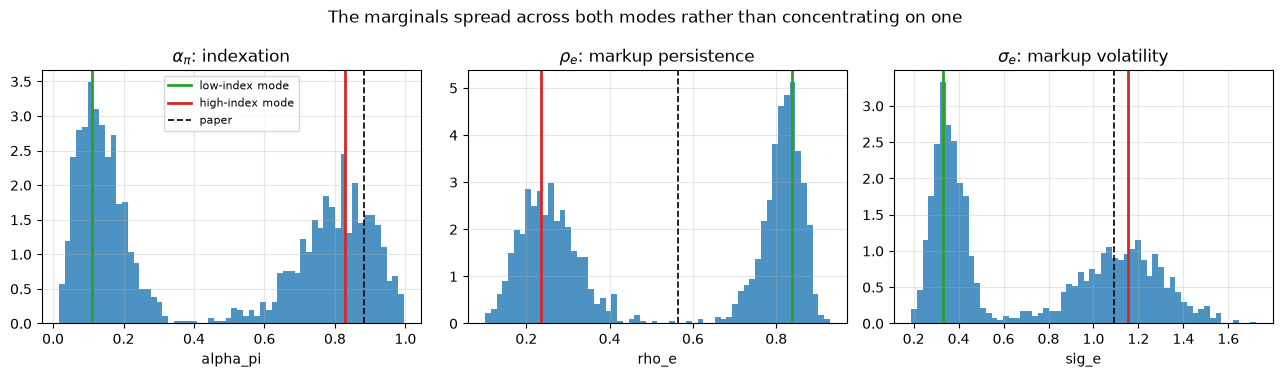

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, n, ttl in zip(axes, ['alpha_pi', 'rho_e', 'sig_e'],
                      [r'$\alpha_\pi$: indexation',
                       r'$\rho_e$: markup persistence',
                       r'$\sigma_e$: markup volatility']):
    i = FREE.index(n)
    ax.hist(nuts_kept[:, i], bins=60, density=True, color='C0', alpha=0.8)
    ax.axvline(v_mode_a[i], color='C2', lw=2, label='low-index mode')
    ax.axvline(v_mode[i], color='C3', lw=2, label='high-index mode')
    ax.axvline(PAPER[n], color='k', ls='--', lw=1.2, label='paper')
    ax.set(title=ttl, xlabel=n)
axes[0].legend(fontsize=8)
fig.suptitle('The marginals spread across both modes rather than concentrating on one')
fig.tight_layout()
plt.show()

这些边缘分布很宽且呈现出块状，而不是其他每个参数所呈现的那种整齐的钟形曲线。

各条链确实在两个区域之间移动，但移动得很缓慢，而这种缓慢的移动正是那些较差的有效样本量所反映出来的情况。

三万次随机游走抽样根本从未完成过这次移动。

这两个众数背后的经济学解释是一个熟悉的识别问题。

1960-1983 年的数据无法告诉我们，通货膨胀之所以具有持续性，究竟是因为价格被指数化到过去的通货膨胀，还是因为推动通货膨胀波动的冲击本身就具有持续性。

两种叙事都能拟合数据，而已发表的估计值所描述的正是数据略微不太偏好的那一个。

### 双峰性是否改变了经济学结论？

这是对本讲座其余部分而言最重要的问题。

In [46]:
h_mode_a = h_zero(unpack(v_mode_a))
h_mode_b = h_zero(unpack(v_mode))
print(f'h(0) at the low-indexation mode   {h_mode_a[0]:.4f}, {h_mode_a[1]:.4f}')
print(f'h(0) at the high-indexation mode  {h_mode_b[0]:.4f}, {h_mode_b[1]:.4f}')

h_nuts = np.array([h_zero(unpack(v)) for v in nuts_kept])
low = nuts_kept[:, FREE.index('alpha_pi')] < 0.5
print(f'\n{low.sum()} of {len(low)} NUTS draws sit on the low-indexation side')
for tag, m in [('low-indexation draws ', low), ('high-indexation draws', ~low)]:
    if m.sum() < 20:
        continue
    print(f'{tag}  h_pi {h_nuts[m, 0].mean():.4f} '
          f'[{np.percentile(h_nuts[m, 0], 5):.4f}, {np.percentile(h_nuts[m, 0], 95):.4f}]'
          f'   h_R {h_nuts[m, 1].mean():.4f} '
          f'[{np.percentile(h_nuts[m, 1], 5):.4f}, {np.percentile(h_nuts[m, 1], 95):.4f}]')

h(0) at the low-indexation mode   0.8631, 0.8290
h(0) at the high-indexation mode  0.9764, 0.7696

834 of 1600 NUTS draws sit on the low-indexation side
low-indexation draws   h_pi 0.8150 [0.5900, 0.9568]   h_R 0.7490 [0.4325, 0.9133]
high-indexation draws  h_pi 0.9565 [0.8630, 1.0077]   h_R 0.7621 [0.5633, 0.9001]



834 of 1600 NUTS draws sit on the low-indexation side
low-indexation draws   h_pi 0.8150 [0.5900, 0.9568]   h_R 0.7490 [0.4325, 0.9133]
high-indexation draws  h_pi 0.9565 [0.8630, 1.0077]   h_R 0.7621 [0.5633, 0.9001]


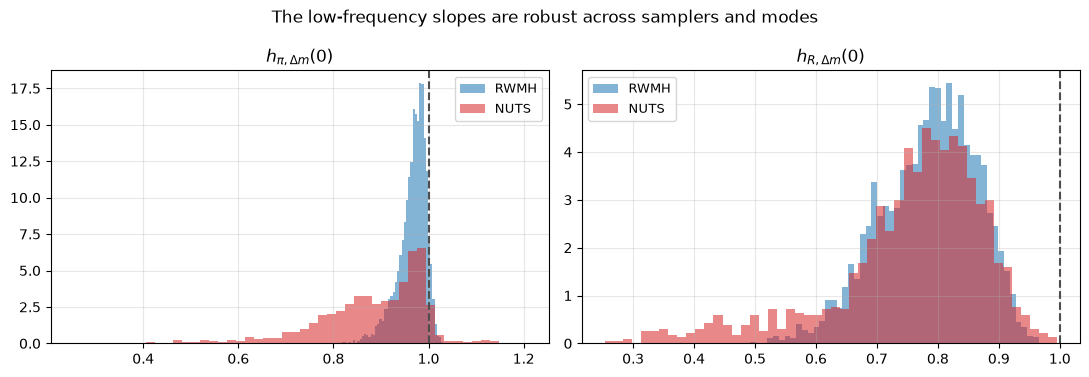

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, j, ttl in zip(axes, [0, 1],
                      [r'$h_{\pi,\Delta m}(0)$', r'$h_{R,\Delta m}(0)$']):
    ax.hist(h_draws[:, j], bins=50, density=True, alpha=0.55,
            color='C0', label='RWMH')
    ax.hist(h_nuts[:, j], bins=50, density=True, alpha=0.55,
            color='C3', label='NUTS')
    ax.axvline(1, color='0.3', ls='--', lw=1.5)
    ax.set_title(ttl)
    ax.legend(fontsize=9)
fig.suptitle('The low-frequency slopes are robust across samplers and modes')
plt.tight_layout()
plt.show()

令人放心的答案是：并没有改变。

这两个众数在通货膨胀*为何*具有持续性这一问题上分歧很大，但在本讲座所关注的低频斜率上分歧却小得多。

无论通货膨胀持续性是内生的还是继承而来的，$h_{\pi,\Delta m}(0)$ 都保持在大约五分之四到一之间，而 $h_{R,\Delta m}(0)$ 在两种情形下都接近五分之四。

论文的实质性结论在其参数估计描述的只是一个局部众数这一发现面前依然站得住脚。

### 比较两种采样器

解决了这个问题之后，我们可以回到效率问题上来。

区分两个众数的那三个参数的有效样本量在两种采样器之间不能直接比较，因为对 NUTS 而言，这些量部分反映的是众数*之间*的移动，而对随机游走而言，反映的是单一众数*内部*的移动。

因此我们比较中位数而不是最小值。

In [48]:
compare = pd.DataFrame({
    'RWMH mean': rwmh_summary['mean'], 'NUTS mean': nuts_summary['mean'],
    'RWMH ESS': rwmh_summary['ess_bulk'], 'NUTS ESS': nuts_summary['ess_bulk'],
    'NUTS r_hat': nuts_summary['r_hat']})
compare['ESS ratio'] = compare['NUTS ESS'] / compare['RWMH ESS']
compare.round(3)

,RWMH mean,NUTS mean,RWMH ESS,NUTS ESS,NUTS r_hat,ESS ratio
theta,0.989,0.989,294.997,1629.139,1.003,5.523
alpha_pi,0.823,0.457,341.191,7.109,1.549,0.021
kappa,0.117,0.122,90.964,27.450,1.098,0.302
alpha_x,0.379,0.321,26.169,7.079,1.568,0.270
sigma,0.083,0.077,44.778,19.576,1.140,0.437
xi,3.482,3.002,62.647,8.107,1.441,0.129
gamma,2.051,1.676,75.848,6.650,1.635,0.088
phi_pi,-0.226,-0.305,278.450,12.307,1.243,0.044
phi_x,-0.788,-0.839,61.905,44.899,1.066,0.725
rho_m,0.516,0.496,237.557,10.372,1.305,0.044


In [49]:
unimodal = ~nuts_summary.index.isin(worst)
r_med = rwmh_summary['ess_bulk'][unimodal].median()
n_med = nuts_summary['ess_bulk'][unimodal].median()

print(f'{"":26s}{"RWMH":>12s}{"NUTS":>12s}')
print(f'{"draws kept":26s}{len(kept):12d}{len(nuts_kept):12d}')
print(f'{"seconds":26s}{rwmh_seconds:12.0f}{nuts_seconds:12.0f}')
print(f'{"median ESS":26s}{r_med:12.0f}{n_med:12.0f}')
print(f'{"median ESS per 1000 draws":26s}{1000 * r_med / len(kept):12.1f}'
      f'{1000 * n_med / len(nuts_kept):12.1f}')
print(f'{"median ESS per second":26s}{r_med / rwmh_seconds:12.2f}'
      f'{n_med / nuts_seconds:12.2f}')
print(f'\n{"speed-up in ESS per second":30s}'
      f'{(n_med / nuts_seconds) / (r_med / rwmh_seconds):6.1f}x')

                                  RWMH        NUTS
draws kept                        4000        1600
seconds                            186         317
median ESS                          91           9
median ESS per 1000 draws         22.7         5.7
median ESS per second             0.49        0.03

speed-up in ESS per second       0.1x


按每次抽样计算，差距非常大，因为每一次 NUTS 抽样都是一条穿越后验分布的轨迹的终点，而不是迈出的一小步随机步伐。

计算代价则挽回了一部分差距，因为一次 NUTS 迭代需要多次梯度评估，而一次随机游走迭代只需要一次似然评估。

真正重要的比值是每秒的有效抽样数，而它仍然大幅度地偏向 NUTS。

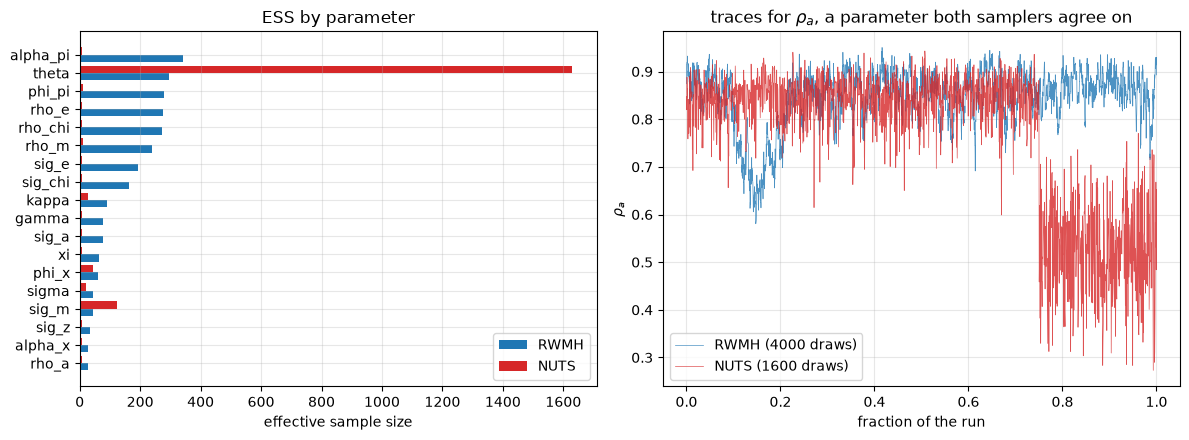

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = np.argsort(rwmh_summary['ess_bulk'].values)
pos = np.arange(len(FREE))
axes[0].barh(pos - 0.2, rwmh_summary['ess_bulk'].values[order], 0.4,
             label='RWMH', color='C0')
axes[0].barh(pos + 0.2, nuts_summary['ess_bulk'].values[order], 0.4,
             label='NUTS', color='C3')
axes[0].set(yticks=pos, yticklabels=[FREE[i] for i in order],
            xlabel='effective sample size', title='ESS by parameter')
axes[0].legend()

j = FREE.index('rho_a')
axes[1].plot(np.linspace(0, 1, len(kept)), kept[:, j], lw=0.5, color='C0',
             alpha=0.8, label=f'RWMH ({len(kept)} draws)')
axes[1].plot(np.linspace(0, 1, len(nuts_kept)), nuts_kept[:, j], lw=0.5,
             color='C3', alpha=0.8, label=f'NUTS ({len(nuts_kept)} draws)')
axes[1].set(xlabel='fraction of the run', ylabel=r'$\rho_a$',
            title=r'traces for $\rho_a$, a parameter both samplers agree on')
axes[1].legend()
fig.tight_layout()
plt.show()

### 应当汲取的教训

在 DSGE 估计中阻碍哈密顿方法应用的是模型求解器，而不是统计学本身。

用一个只涉及线性代数的不动点求解器，替代一个对特征值进行排序的求解器，能以大约多花一次似然评估的代价换来精确的梯度，而这足以让 NUTS 变得触手可及。

收获不仅仅在于速度。

低成本的链使得同时运行多条链并检查其诊断指标变得便宜，而混合最差的那些参数恰恰指向了一个更好的第二众数，而三万次随机游走抽样从未到访过那里。

有两点值得说明。

第一，在不存在稳定解的地方，不动点方法会返回没有意义的结果，因此一个游荡到可决区域之外的采样器会产生胡言乱语，而不是被拒绝；这里的后验分布很好地落在该区域内部，但一个更平坦的后验分布可能不会。

第二，上面报告的效率提升是针对这一特定后验分布而言的，一个维度更少、尺度更好的后验分布会大大缩小这一差距。

## 结束语

{cite:t}`Lucas1980` 曾谨慎地说明，他的两个单位斜率应当预期在某些货币政策下成立，而在另一些货币政策下失效。

将他的样本延伸半个世纪，证实了这些失效情形。

在一个类似他所用的样本上估计一个小型结构模型，然后只改变货币政策规则，就能产生跨越数据所显示的大部分范围的斜率。

这正是卢卡斯、{cite:t}`Sargent1971` 以及 {cite:t}`Whiteman1984` 都得出的教训，即低频回归系数并非结构性的。

从零开始梳理这一模型，为论文的论述增添了一些内容。

卢卡斯的第一个例证，即通货膨胀对货币增长的单位斜率，在这一模型中，只要货币增长在计量上是外生的，就是一个*恒等式*，因为货币需求是一个数量方程，其余各项都是一阶差分。

他的第二个例证，即利率对货币增长的单位斜率，则没有这样的支撑，可以自由地变动。

因此，这两个在散点图上看起来对称的例证，从结构模型的视角来看，其实是相当不同的对象。

正如 {ref}`ss_ex2` 所揭示的那样，这种不对称性也标出了这一练习的局限所在。

由于 $h_{\pi,\Delta m}(0)$ 被货币需求锚定在一，要将其驱动到 1984 年后数据所显示的接近零的值，需要一个远比这些数据实际选定的规则更具反通胀性的货币增长规则。

在计算方面，这一模型证明是哈密顿蒙特卡洛的一个有用测试平台。

将其用于 DSGE 模型的障碍并非统计上的，而是算法上的：标准求解器要对特征值排序，而排序没有导数。

换入一个只用线性代数的不动点求解器，就能恢复精确的梯度，而由此获得的采样器在像这里这样尺度很差的后验分布上，单位计算时间内的效率要高得多。

更大的收获是诊断上的。

低成本的链及其收敛诊断，把我们引向了第二个众数，而后验分布结果是双峰的：数据无法在内生的和继承而来的通货膨胀持续性之间做出选择，而最接近已发表估计值的众数恰恰是两者中较*低*的那一个。

尽管如此，这两个众数在 $h_{\pi,\Delta m}(0)$ 和 $h_{R,\Delta m}(0)$ 上却达成一致，这对论文来说是一则好消息，而这只有借助更彻底的采样器才能揭示出来。

## 练习

```{exercise}
:label: ss_ex1

论文假设技术增长是序列不相关的。

将 $z_t = \varepsilon_{zt}$ 替换为 $z_t = \rho_z z_{t-1} + \varepsilon_{zt}$，并回答两个问题。

{prf:ref}`ss_prop` 是否依然成立？持续性的技术增长是否提供了一条与货币政策无关、打破单位斜率的途径？
```

```{solution-start} ss_ex1
:class: dropdown
```

技术冲击块是规范形式的第 7 行，其中 `g1[7, Z]` 目前为零。

In [51]:
def canonical_rho_z(p, rule='money'):
    g0, g1, psi, pie = canonical(p, rule)
    g1[7, Z] = p['rho_z']
    return g0, g1, psi, pie


def h_zero_rho_z(p):
    G1, impact, eu = gensys(*canonical_rho_z(p))
    if eu != (1, 1):
        return np.nan, np.nan
    sd = np.diag([p['sig_e'], p['sig_a'], p['sig_chi'], p['sig_z'], p['sig_m']])
    n = NY + 2
    A, B = np.zeros((n, n)), np.zeros((n, 5))
    A[:NY, :NY], A[NY, X], A[NY + 1, A_] = G1, 1, 1
    B[:NY] = impact @ sd
    C = np.zeros((4, n))
    C[0, DM], C[1, PI], C[2, R], C[3, Z] = 1, 1, 1, 1
    C[3, X], C[3, NY] = 1, -1
    C[3, A_], C[3, NY + 1] = p['xi'], -p['xi']
    if np.max(np.abs(np.linalg.eigvals(A))) > 1 - 1e-9:
        return np.nan, np.nan
    return (h_zero_from_state_space(A, B, C, 1, 0),
            h_zero_from_state_space(A, B, C, 2, 0))


print('exogenous money growth, phi_pi = phi_x = 0')
for rho_z in [0.0, 0.3, 0.6, 0.9]:
    q = dict(p_bar, phi_pi=0.0, phi_x=0.0, rho_z=rho_z)
    print(f'   rho_z = {rho_z:.1f}:  h_pi = {h_zero_rho_z(q)[0]:.10f}, '
          f'h_R = {h_zero_rho_z(q)[1]:.4f}')

print('\nwith policy feedback, phi_pi = -2, phi_x = -0.5')
for rho_z in [0.0, 0.3, 0.6, 0.9]:
    q = dict(p_bar, phi_pi=-2.0, phi_x=-0.5, rho_z=rho_z)
    print(f'   rho_z = {rho_z:.1f}:  h_pi = {h_zero_rho_z(q)[0]:.4f}, '
          f'h_R = {h_zero_rho_z(q)[1]:.4f}')

exogenous money growth, phi_pi = phi_x = 0
   rho_z = 0.0:  h_pi = 1.0000000000, h_R = 0.4083
   rho_z = 0.3:  h_pi = 1.0000000000, h_R = 0.4083
   rho_z = 0.6:  h_pi = 1.0000000000, h_R = 0.4083
   rho_z = 0.9:  h_pi = 1.0000000000, h_R = 0.4083

with policy feedback, phi_pi = -2, phi_x = -0.5
   rho_z = 0.0:  h_pi = 0.4907, h_R = 0.7834
   rho_z = 0.3:  h_pi = 0.2350, h_R = 0.6453
   rho_z = 0.6:  h_pi = -0.1349, h_R = 0.3090
   rho_z = 0.9:  h_pi = -0.4586, h_R = -0.2811


{prf:ref}`ss_prop` 依然完好无损地成立，因为它的证明只用到了技术与政策冲击是正交的这一事实，而从未用到技术具有多大的持续性。

在货币增长外生的情形下，*两个*斜率都对 $\rho_z$ 保持不变，这一点值得留意其原因：$z_t$ 只在同期通过货币需求进入模型，因此 $\rho_z$ 改变了技术的动态，却不改变任何人对货币冲击的反应。

一旦政策存在反馈，情况就不同了，持续性的技术增长会把 $h_{\pi,\Delta m}(0)$ 大幅拉离一。

因此第二个问题的答案是肯定的，而这也指出了论文实验的一个局限：技术过程在政策变化时被固定不变，而这两者实际上是相互作用的。

```{solution-end}
```

```{exercise}
:label: ss_ex2

本讲座在 1960:I-1983:IV 上估计模型。

在 1984:I-2007:IV 上找出后验众数，并将政策系数以及蕴含的 $h(0)$ 与我们在较早样本上得到的结果进行比较。

VAR 显示 1984-2007 年间 $h_{\pi,\Delta m}(0)$ 接近零，重新估计后的结构模型是否与之一致？
```

```{solution-start} ss_ex2
:class: dropdown
```

In [52]:
mask2 = (data.index.year >= 1984) & (data.index.year <= 2007)
Y2 = data.loc[mask2, VARS].values
Y2 = Y2 - Y2.mean(0)

res2 = optimize.minimize(lambda v: -log_post(v, Y2), v_mode, method='Powell',
                         options=dict(maxiter=20000, maxfev=20000))
res2 = optimize.minimize(lambda v: -log_post(v, Y2), res2.x, method='L-BFGS-B',
                         bounds=[SUPPORT[n] for n in FREE])
v2 = res2.x
print('                       1960-1983    1984-2007')
for n in ['phi_pi', 'phi_x', 'rho_m']:
    j = FREE.index(n)
    print(f'   {n:9s} {v_mode[j]:11.4f} {v2[j]:12.4f}')
print('   %-9s %5.3f, %.3f  %5.3f, %.3f'
      % (('model h(0)',) + h_zero(unpack(v_mode)) + h_zero(unpack(v2))))
for name, lo, hi in [('1960-1983', 1960, 1983), ('1984-2007', 1984, 2007)]:
    m = (data.index.year >= lo) & (data.index.year <= hi)
    med = np.nanmedian(bvar_h0(data.loc[m, VARS].values), axis=0)
    print(f'   VAR   h(0) on {name}: {med[0]:.3f}, {med[1]:.3f}')

                       1960-1983    1984-2007
   phi_pi        -0.1961      -0.0400
   phi_x         -0.5745      -1.5634
   rho_m          0.5300       0.3080
   model h(0) 0.976, 0.770  0.989, 0.858
   VAR   h(0) on 1960-1983: 0.739, 0.607
   VAR   h(0) on 1984-2007: -0.073, 0.268


   VAR   h(0) on 1984-2007: -0.073, 0.268


重新估计的模型*并不*与 VAR 一致。

政策系数发生了变化，但蕴含的 $h_{\pi,\Delta m}(0)$ 在两个样本上都保持接近一，而 VAR 在 1984 年后将其估计为接近零。

{prf:ref}`ss_prop` 解释了为什么这必定是困难的。

在这一模型中，$h_{\pi,\Delta m}(0)$ 被锚定在一，只有政策反馈才能将其拉离，因此要达到接近零的值需要一个很大的负 $\phi_\pi$，而 1984 年后的数据并没有将货币增长规则推向那个方向的任何地方。

这是论文第二节与第三节之间一个真实存在的张力：等高线图显示存在一种*可能*产生低斜率的政策规则，但后期数据实际选定的规则并非那种规则。

一个完整的比较应当在两个样本上都运行采样器，而不是仅仅比较众数。

```{solution-end}
```

```{exercise}
:label: ss_ex3

论文的图 8 探讨了供给冲击方差的下降，而非政策的改变，是否能够解释 $h(0)$ 的下降。

将 $\sigma_e$ 削减为其后验均值的四分之一，重新绘制货币规则等高线图，并报告该图变化了多少。
```

```{solution-start} ss_ex3
:class: dropdown
```

baseline    h_pi in [0.09, 1.06],  h_R in [0.06, 1.21]
small sig_e h_pi in [0.09, 1.06],  h_R in [0.06, 1.00]
largest change in h_pi across the grid: 0.435


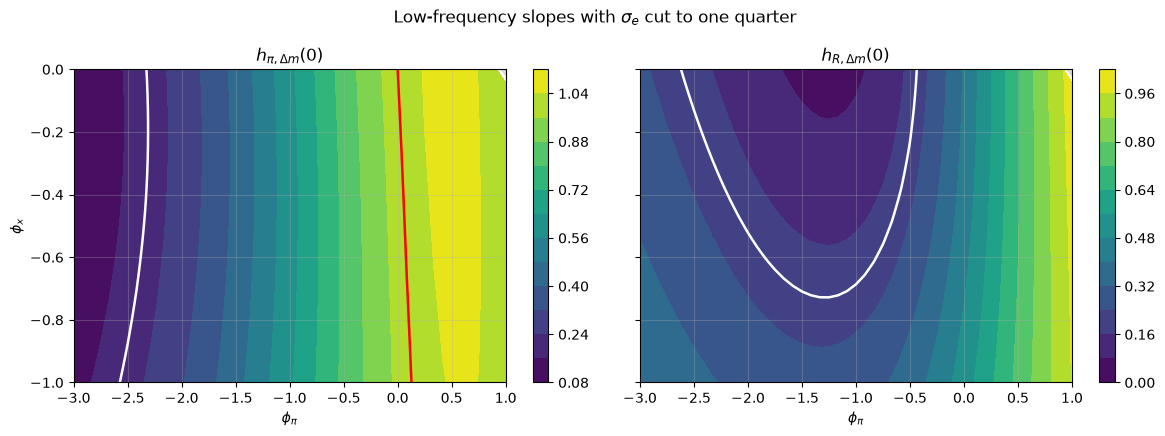

In [53]:
p_small_e = dict(p_bar, sig_e=p_bar['sig_e'] / 4)
Hpi2, HR2 = h_grid(p_small_e, 'money', 'phi_pi', 'phi_x',
                   phi_pi_grid, phi_x_grid)

print('baseline    h_pi in [%.2f, %.2f],  h_R in [%.2f, %.2f]'
      % (np.nanmin(Hpi), np.nanmax(Hpi), np.nanmin(HR), np.nanmax(HR)))
print('small sig_e h_pi in [%.2f, %.2f],  h_R in [%.2f, %.2f]'
      % (np.nanmin(Hpi2), np.nanmax(Hpi2), np.nanmin(HR2), np.nanmax(HR2)))
print('largest change in h_pi across the grid: %.3f'
      % np.nanmax(np.abs(Hpi2 - Hpi)))

contour_panel(phi_pi_grid, phi_x_grid, Hpi2, HR2, r'$\phi_\pi$', r'$\phi_x$',
              r'Low-frequency slopes with $\sigma_e$ cut to one quarter')

$h_{\pi,\Delta m}(0)$ 所能达到的范围没有变化，从政策到 $h(0)$ 的映射也保持相同的形状。

等高线确实在该范围内发生了移动，在某些网格点上移动幅度达到了十分之几，因此并不能说冲击方差是无关紧要的。

论文所主张的是一个更弱的说法，即这种量级的冲击方差变化，不足以替代政策的变化。

```{solution-end}
```